In [ ]:
"""
20 Feb 2026
transition_plots.py
====================
Generates two key diagnostic plots for the extended Abrams-Strogatz model:

PLOT 1 — Transition vector field
    Shows how the fixed point classification changes from saddle to stable node
    as the indigenous population I crosses the logistic inflection point K_I/2.
    We perturb I around year 2007 (when I ≈ K_I/2) and plot 5 fixed points
    simultaneously to visualize the red→green transition.

PLOT 2 — Dual-regime comparison
    Compares the effect of the demographic term g(x_o) in two historical periods:
      - Consensus (a=1.25, 1895-1970): g creates a stable interior fixed point
      - Coexistence (a=0.655, 1970-2020): g shifts an existing stable fixed point
    
    Shows f(x_o) [ASM alone] vs f(x_o)+g(x_o) [complete system] at year 1970.

Author: Riccardo Del Gratta, with Claude assistance
Date: February 2025
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.optimize import brentq
import warnings

# ===========================================================================
# MODEL PARAMETERS
# ===========================================================================
# These are calibrated from Mexican census data (1895-2020)

# Indigenous population logistic growth
N0_indigenous = 1012848      # Initial population at t=0 (year 1895)
K_indigenous = 12918933      # Carrying capacity
r_indigenous = 0.022         # Growth rate (yr^-1)

# Spanish population logistic growth
N0_spanish = 3117878         # Initial population at t=0
K_spanish = 165995301        # Carrying capacity
r_spanish = 0.037            # Growth rate (yr^-1)

# Bilingual birth probability parameters
A_p = 5.47                   # Sigmoid shape parameter
nu = 0.271                   # Sensitivity to m_si ratio
p_max = 0.97                 # Maximum probability

# ASM parameters for COEXISTENCE regime (1970–2020)
s_o_coex = 0.047             # Spanish prestige
s_l_coex = 0.015             # Indigenous prestige
a_coex = 0.6553              # Volatility (a < 1 → stable interior fixed point)

# ASM parameters for CONSENSUS regime (1895–1970)
s_o_cons = 0.0349            # Spanish prestige
s_l_cons = 0.0055            # Indigenous prestige
a_cons = 1.25                # Volatility (a > 1 → unstable interior, boundary attractors)

base_year = 1895             # Reference year (t=0)

# ===========================================================================
# COMPUTE THE TRANSITION YEAR (when I = K_I/2)
# ===========================================================================
# This is the year when J11 = r_I(1 - 2I/K_I) changes sign from + to -.
# It's purely demographic — the inflection point of the logistic curve for I(t).

T_CROSS = brentq(
    # This anonymous function computes I(t) - K_I/2
    # We're finding the time t where this equals zero
    lambda t: K_indigenous / (1 + ((K_indigenous-N0_indigenous)/N0_indigenous)
                               * np.exp(-r_indigenous*t)) - K_indigenous/2,
    0, 300  # Search between t=0 and t=300 years
)
YEAR_CROSS = base_year + T_CROSS  # Convert to calendar year


# ===========================================================================
# CORE MATHEMATICAL FUNCTIONS
# ===========================================================================

def logistic(t, K, r, N0):
    """
    Standard logistic growth function: N(t) = K / (1 + C*exp(-rt))
    where C = (K-N0)/N0 is determined by the initial condition.
    
    Parameters
    ----------
    t : float
        Time since base_year (years)
    K : float
        Carrying capacity (maximum population)
    r : float
        Growth rate (yr^-1)
    N0 : float
        Initial population at t=0
        
    Returns
    -------
    float
        Population at time t
        
    Notes
    -----
    The inflection point (maximum growth rate) occurs at N = K/2, which
    corresponds to time t* = (1/r) * ln(C) where C = (K-N0)/N0.
    """
    return K / (1 + ((K-N0)/N0)*np.exp(-r*t))


def p_o_func(m):
    """
    Probability that a newborn indigenous individual is bilingual.
    
    This is a sigmoid function of the Spanish-to-indigenous ratio m_si = S/I.
    As m_si increases (more Spanish speakers per indigenous speaker), the
    probability of being born bilingual increases, saturating at p_max.
    
    Parameters
    ----------
    m : float
        Spanish-to-indigenous ratio m_si = S(t)/I(t)
        
    Returns
    -------
    float
        Probability p_o ∈ (0, p_max)
        
    Formula
    -------
    p_o(m) = p_max / (1 + A * exp(-ν * m))
    
    This is a logistic (sigmoid) function:
    - When m → 0 (few Spanish speakers): p_o → 0
    - When m → ∞ (many Spanish speakers): p_o → p_max
    - The parameter ν controls how sensitive p_o is to changes in m
    """
    return p_max / (1 + A_p*np.exp(-nu*m))


def f_func(x_o, s_o, s_l, a):
    """
    Abrams-Strogatz prestige function.
    
    This encodes linguistic conversions (Monolingual ↔ Bilingual) driven by
    prestige differences. It's the "internal dynamics" of the ASM model,
    evaluated at constant population.
    
    Parameters
    ----------
    x_o : float or array
        Bilingual fraction of indigenous population (0 ≤ x_o ≤ 1)
    s_o : float
        Prestige of Spanish language
    s_l : float
        Prestige of indigenous language
    a : float
        Volatility parameter
        
    Returns
    -------
    float or array
        Rate of change dx_o/dt from ASM dynamics alone
        
    Formula
    -------
    f(x_o) = s_o * x_o^a * (1-x_o) - s_l * (1-x_o)^a * x_o
    
    The two terms represent:
    - First term: Monolinguals (fraction 1-x_o) becoming bilingual
    - Second term: Bilinguals (fraction x_o) reverting to monolingual
    
    Fixed points occur where f(x_o) = 0:
    - Always at x_o=0 and x_o=1 (boundary fixed points)
    - Interior fixed point at x_o* = 1/(1+β) where β = (s_o/s_l)^(1/(a-1))
    
    Stability of interior fixed point:
    - If a > 1: interior is UNSTABLE (repels trajectories)
    - If a < 1: interior is STABLE (attracts trajectories)
    
    Notes
    -----
    We handle boundaries carefully to avoid power-law singularities when a < 1.
    The exponents a-1 and a-2 in the derivative can be negative, causing
    division-by-zero at x_o=0 or x_o=1.
    """
    # Scalar case (single x_o value)
    if np.ndim(x_o) == 0:
        if x_o <= 0 or x_o >= 1:
            return 0.0  # Zero at boundaries (no change possible)
        # Suppress RuntimeWarning from negative exponents
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            return s_o*(x_o**a)*(1-x_o) - s_l*((1-x_o)**a)*x_o
    
    # Array case (multiple x_o values for plotting)
    else:
        x = np.asarray(x_o, dtype=float)
        out = np.zeros_like(x)
        # Only compute where 0 < x < 1 (interior)
        mask = (x > 0) & (x < 1)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            out[mask] = s_o*(x[mask]**a)*(1-x[mask]) - s_l*((1-x[mask])**a)*x[mask]
        return out


def g_func(x_o, p, m_val, I, s_o, s_l, a):
    """
    Natural increment function: demographic contribution to dx_o/dt.
    
    This term captures the effect of population growth on the bilingual fraction.
    It has three components (derived via quotient rule):
      1. New bilingual births at rate p_o * (dI/dt)
      2. Evolution of p_o itself as m_si changes
      3. Quotient-rule correction from x_o = X_o/I
    
    Parameters
    ----------
    x_o : float
        Bilingual fraction
    p : float
        Bilingual birth probability p_o(m_si)
    m_val : float
        Spanish-to-indigenous ratio m_si = S/I
    I : float
        Indigenous population
    s_o, s_l, a : float
        ASM parameters (not used here, kept for API consistency)
        
    Returns
    -------
    float
        Contribution to dx_o/dt from demographic processes
        
    Formula
    -------
    g(x_o, I) = [p_o - x_o - p_o(1-p_o/p_max)νm_si] * r_I(1 - I/K_I)
    
    The bracket combines three effects:
    - p_o: injection of new bilingual births
    - -x_o: quotient rule correction (denominator I growing)
    - -p_o(1-p_o/p_max)νm_si: evolution of p_o as I changes
    
    The factor r_I(1-I/K_I) is dI/dt / I (logistic growth rate per capita).
    """
    # The bracket [p_o - x_o - ...]
    bracket = p - x_o - p*(1-p/p_max)*nu*m_val
    
    # Logistic growth factor: (1/I) * dI/dt = r_I(1 - I/K_I)
    logistic_factor = r_indigenous*(1 - I/K_indigenous)
    
    return bracket * logistic_factor


def rhs(x_o, I, S, s_o, s_l, a):
    """
    Full right-hand side of the extended model equation.
    
    This computes dx_o/dt = f(x_o) + g(x_o, I, S) for given (x_o, I, S).
    
    Parameters
    ----------
    x_o : float
        Bilingual fraction
    I : float
        Indigenous population
    S : float
        Spanish population (held fixed in quasi-static approximation)
    s_o, s_l, a : float
        ASM parameters for the chosen regime
        
    Returns
    -------
    float
        Total rate of change dx_o/dt
        
    Notes
    -----
    Fixed points of the system satisfy rhs(x_o*, I, S) = 0.
    The stability is determined by the Jacobian eigenvalues:
      λ₁ = ∂rhs/∂x_o = J00  (x_o-direction)
      λ₂ = ∂(dI/dt)/∂I = J11 = r_I(1 - 2I/K_I)  (I-direction)
    """
    # Compute derived quantities
    m_val = S/I if I > 0 else np.inf
    p = p_o_func(m_val)
    
    # Sum ASM term + demographic term
    return f_func(x_o, s_o, s_l, a) + g_func(x_o, p, m_val, I, s_o, s_l, a)


def find_fp(I_val, S_val, s_o, s_l, a, n=3000):
    """
    Find all fixed points x_o* at given (I, S) values.
    
    Strategy: scan for sign changes, then refine with Brent's method.
    This is robust even when the function has multiple roots or nearly
    touches zero without crossing.
    
    Parameters
    ----------
    I_val, S_val : float
        Population values at which to find fixed points
    s_o, s_l, a : float
        ASM parameters
    n : int
        Number of scan points (higher = more reliable root detection)
        
    Returns
    -------
    list of float
        All fixed points x_o* ∈ (0,1) where rhs(x_o*, I_val, S_val) = 0
        
    Algorithm
    ---------
    1. Evaluate rhs on a dense grid [0.005, 0.995]
    2. Find intervals where sign changes (indicates a root)
    3. For each sign change, use Brent's method to refine the root
    
    Why Brent's method?
    - Guaranteed convergence when bracketed by sign change
    - No need for derivative (unlike Newton)
    - Robust to singularities at boundaries
    """
    # Dense scan grid
    xs = np.linspace(0.005, 0.995, n)
    
    # Evaluate rhs at all grid points
    vals = np.array([rhs(x, I_val, S_val, s_o, s_l, a) for x in xs])
    
    # Find where sign changes (indicates root between consecutive points)
    sign_changes = np.where(np.diff(np.sign(vals)))[0]
    
    roots = []
    for idx in sign_changes:
        try:
            # Brent's method: finds root in interval [xs[idx], xs[idx+1]]
            xr = brentq(
                lambda x: rhs(x, I_val, S_val, s_o, s_l, a),
                xs[idx], xs[idx+1],
                xtol=1e-10  # Tolerance: root accuracy to 10 decimal places
            )
            roots.append(xr)
        except Exception:
            # If Brent fails (shouldn't happen with sign change), skip
            pass
    
    return roots


def classify(x_o, I_val, S_val, s_o, s_l, a, eps=1e-6):
    """
    Classify a fixed point by computing J00 and J11.
    
    The Jacobian of the system is upper-triangular:
    
        J = [ J00  J01 ]
            [  0   J11 ]
    
    Eigenvalues are λ₁=J00 (x_o direction) and λ₂=J11 (I direction).
    
    Classification:
      - Both negative → Stable node (attracts in all directions)
      - One negative, one positive → Saddle (attracts in one dir, repels in other)
      - Both positive → Unstable node (repels in all directions)
    
    Parameters
    ----------
    x_o : float
        Fixed point x_o-coordinate
    I_val, S_val : float
        Population values at fixed point
    s_o, s_l, a : float
        ASM parameters
    eps : float
        Finite difference step size
        
    Returns
    -------
    fully_stable : bool
        True if stable node (both eigenvalues negative)
    saddle : bool
        True if saddle (eigenvalues of opposite signs)
    J00 : float
        Eigenvalue in x_o direction
    J11 : float
        Eigenvalue in I direction
        
    Notes
    -----
    We compute J00 numerically because the analytical derivative has
    power-law singularities when a < 1.
    
    J11 is computed analytically from the logistic equation:
        dI/dt = r_I * I * (1 - I/K_I)
        ⟹ ∂(dI/dt)/∂I = r_I(1 - 2I/K_I)
    
    This changes sign at I = K_I/2 (the logistic inflection point).
    """
    # Compute derived quantities at the fixed point
    m_val = S_val/I_val
    p = p_o_func(m_val)
    
    # --- Compute J00 numerically using centered finite differences ---
    # J00 = ∂rhs/∂x_o evaluated at (x_o, I_val, S_val)
    
    # Perturb x_o by ±eps, staying away from boundaries
    xp = min(x_o + eps, 0.995)
    xm = max(x_o - eps, 0.005)
    
    # Centered difference: (f(x+h) - f(x-h)) / (2h)
    J00 = (rhs(xp, I_val, S_val, s_o, s_l, a) 
           - rhs(xm, I_val, S_val, s_o, s_l, a)) / (xp - xm)
    
    # --- Compute J11 analytically ---
    # J11 = ∂(dI/dt)/∂I = r_I - 2*r_I*I/K_I = r_I(1 - 2I/K_I)
    J11 = r_indigenous*(1 - 2*I_val/K_indigenous)
    
    # --- Classify based on eigenvalue signs ---
    fully_stable = (J00 < 0) and (J11 < 0)  # Both attracting
    saddle = (J00 < 0) and (J11 > 0)         # One attracting, one repelling
    
    return fully_stable, saddle, J00, J11


# ===========================================================================
# PLOT 1 — TRANSITION VECTOR FIELD (two-panel: before / after 2007)
# ===========================================================================

def _draw_one_phase_portrait(ax, t_bar, s_o, s_l, a,
                              n_I_pts=5, delta_frac=0.20,
                              nx=28, nI=28, I_margin=0.55):
    """
    Draw a single phase-portrait panel on `ax` for the given snapshot time
    and regime parameters.

    This is the workhorse called twice by make_transition_panel() to build
    the before/after figure. It is not meant to be called directly.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes on which to draw.
    t_bar : float
        Snapshot time in years since base_year.
    s_o, s_l, a : float
        Regime-specific ASM parameters.
    n_I_pts : int
        Number of perturbed I values (default 5).
    delta_frac : float
        Half-width of I perturbation as fraction of I(t_bar).
    nx, nI : int
        Streamplot grid resolution.
    I_margin : float
        Vertical extent of plot as fraction of I(t_bar).

    Returns
    -------
    mag : 2-D ndarray
        Vector-magnitude array (used by the caller to build the colorbar).
    mag95 : float
        95th-percentile magnitude (normalisation reference).
    """
    year_bar = int(base_year + t_bar)

    # Population values at this snapshot
    I_center = logistic(t_bar, K_indigenous, r_indigenous, N0_indigenous)
    S_bar    = logistic(t_bar, K_spanish,    r_spanish,    N0_spanish)

    # ----- Perturbed I probe points -----
    delta   = delta_frac * I_center
    I_probe = np.linspace(I_center - delta, I_center + delta, n_I_pts)

    # ----- Find + classify fixed points -----
    fp_data = []
    for I_val in I_probe:
        if I_val <= 0:
            continue
        # Both find_fp and classify use the SAME regime parameters
        roots = find_fp(I_val, S_bar, s_o, s_l, a)
        for xr in roots:
            fs, saddle, J00, J11 = classify(xr, I_val, S_bar, s_o, s_l, a)
            fp_data.append({'x_o': xr, 'I': I_val,
                            'J00': J00, 'J11': J11,
                            'stable': fs, 'saddle': saddle})

    # ----- Vector field grid -----
    x_arr = np.linspace(0.02, 0.98, nx)
    I_lo  = max(I_center*(1 - I_margin), 0.01*K_indigenous)
    I_hi  = min(I_center*(1 + I_margin), 0.999*K_indigenous)
    I_arr = np.linspace(I_lo, I_hi, nI)

    X, IG = np.meshgrid(x_arr, I_arr)
    U = np.zeros_like(X)
    V = np.zeros_like(X)
    for i in range(nI):
        for j in range(nx):
            U[i, j] = rhs(X[i, j], IG[i, j], S_bar, s_o, s_l, a)
            V[i, j] = r_indigenous * IG[i, j] * (1 - IG[i, j]/K_indigenous)

    mag   = np.sqrt(U**2 + V**2)
    mag95 = np.percentile(mag[mag > 0], 95) if np.any(mag > 0) else 1.0
    Un = np.where(mag > 0, U/mag95, 0)
    Vn = np.where(mag > 0, V/mag95, 0)

    # ----- Nullcline (dx_o/dt = 0) -----
    nullcline = []
    for I_val in I_arr:
        if I_val <= 0:
            continue
        xs_nc  = np.linspace(0.005, 0.995, 3000)
        vals_nc = np.array([rhs(x, I_val, S_bar, s_o, s_l, a) for x in xs_nc])
        sc_nc  = np.where(np.diff(np.sign(vals_nc)))[0]
        for idx in sc_nc:
            try:
                xn = brentq(lambda x: rhs(x, I_val, S_bar, s_o, s_l, a),
                            xs_nc[idx], xs_nc[idx+1], xtol=1e-8)
                nullcline.append((xn, I_val))
            except Exception:
                pass

    # ----- Streamplot -----
    norm = mcolors.Normalize(vmin=0, vmax=mag95)
    ax.streamplot(X, IG, Un, Vn, density=1.2,
                  color=mag, cmap='viridis', norm=norm,
                  linewidth=0.8, arrowsize=0.9)

    # ----- Nullcline curve -----
    if nullcline:
        nc_x, nc_I = zip(*sorted(nullcline, key=lambda p: p[1]))
        ax.plot(nc_x, nc_I, color='red', lw=2.0, zorder=4,
                label=r'$\dot{x}_o = 0$ nullcline')

    # ----- Reference lines -----
    ax.axhline(K_indigenous/2, color='black', lw=1.2, ls='-.',
               label=f'$I = K_I/2$  (inflection, year {YEAR_CROSS:.0f})',
               zorder=3)
    ax.axhline(I_center, color='darkorange', lw=1.0, ls=':',
               label=fr'$I(\bar{{t}}) = {I_center:,.0f}$', zorder=3)

    # ----- Fixed points (colour-coded) -----
    J11_vals = [d['J11'] for d in fp_data]
    J11_max  = max(abs(v) for v in J11_vals) if J11_vals else 1.0

    plotted_stable = plotted_saddle = False
    for d in fp_data:
        if d['stable']:
            clr    = '#2ecc40'
            marker = 'o'
            edge   = 'darkgreen'
            lbl    = 'Stable node' if not plotted_stable else '_'
            plotted_stable = True
        else:
            intensity = min(d['J11']/J11_max, 1.0) if J11_max > 0 else 1.0
            clr    = (1.0, max(0, 0.3*(1-intensity)), 0.0)
            marker = 'X'
            edge   = 'darkred'
            lbl    = 'Saddle' if not plotted_saddle else '_'
            plotted_saddle = True
        ax.scatter(d['x_o'], d['I'], color=clr, marker=marker,
                   s=140, zorder=6, edgecolors=edge, linewidths=0.9, label=lbl)

    # ----- Annotations: λ₁, λ₂, I -----
    # We alternate offset direction (right / left) to avoid overlaps
    for k, d in enumerate(fp_data):
        s1 = '+' if d['J00'] >= 0 else ''
        s2 = '+' if d['J11'] >= 0 else ''
        txt = (fr"$\lambda_1={s1}{d['J00']:.4f}$"
               "\n"
               fr"$\lambda_2={s2}{d['J11']:.4f}$"
               "\n"
               fr"$I={d['I']:,.0f}$")

        # Alternate: even indices offset to the right, odd to the left
        x_offset = +0.05 if k % 2 == 0 else -0.32
        ax.annotate(txt,
                    xy=(d['x_o'], d['I']),
                    xytext=(d['x_o'] + x_offset, d['I']),
                    fontsize=6.8, color='black',
                    va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              alpha=0.75, lw=0),
                    arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))

    # ----- Parameter info box (top-left) -----
    m_bar = S_bar / I_center
    p_bar = p_o_func(m_bar)
    param_txt = (f'$s_o={s_o}$, $s_l={s_l}$, $a={a}$\n'
                 f'$p_{{\\max}}={p_max}$, $\\nu={nu}$\n'
                 f'$m_{{si}}={m_bar:.2f}$, $p_o={p_bar:.4f}$')
    ax.text(0.02, 0.99, param_txt, transform=ax.transAxes,
            fontsize=7.5, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.88))

    # ----- Axes labels + title -----
    ax.set_xlabel(r'$x_o$  (bilingual fraction)', fontsize=10)
    ax.set_ylabel(r'$I$  (indigenous population)', fontsize=10)
    ax.set_title(f'$\\bar{{t}}={t_bar:.0f}$  (year {year_bar})', fontsize=11)
    ax.set_xlim(x_arr.min(), x_arr.max())
    ax.set_ylim(I_arr.min(), I_arr.max())
    ax.grid(alpha=0.22)
    ax.legend(fontsize=8, loc='lower right', framealpha=0.9)

    return mag, mag95


def make_transition_panel(t_before, t_after, s_o, s_l, a, regime_label,
                          regime_prefix='regime',
                          n_I_pts=5, delta_frac=0.20,
                          nx=28, nI=28, I_margin=0.55):
    """
    Create a two-panel figure showing the saddle → stable-node transition
    for one regime, comparing a snapshot BEFORE and AFTER year 2007
    (when I crosses K_I/2 and J11 changes sign).

    Each panel shows:
      - Streamplot of the (x_o, I) vector field
      - The x_o-nullcline (dx_o/dt = 0)
      - K_I/2 reference line
      - 5 perturbed fixed points with colour coding:
            green circle  → stable node  (J00<0, J11<0)
            red/orange ×  → saddle       (J00<0, J11>0)
      - Annotation per fixed point: λ₁ = J00, λ₂ = J11, and I

    BUG FIX (vs. original): find_fp and classify now both use the same
    regime parameters (s_o, s_l, a), eliminating the original mismatch
    where find_fp used consensus params but classify used coexistence params.

    Parameters
    ----------
    t_before : float
        Snapshot time (yrs since 1895) BEFORE the 2007 inflection.
        Consensus: 45 (year 1940); Coexistence: 95 (year 1990).
    t_after : float
        Snapshot time AFTER the 2007 inflection.
        Both regimes: 112 (year 2007) or later.
    s_o, s_l, a : float
        Regime-specific ASM parameters.
    regime_label : str
        Short label for the suptitle (e.g. 'Consensus  (a=1.25)').
    n_I_pts, delta_frac, nx, nI, I_margin : see _draw_one_phase_portrait.
    regime_prefix : str
        Short prefix used to name the individual subplot files.
        Each panel is saved as  {regime_prefix}_t{t_bar:.0f}.png
        e.g. 'coex' → 'coex_t95.png', 'coex_t112.png'

    Returns
    -------
    matplotlib.figure.Figure
    """
    kw = dict(s_o=s_o, s_l=s_l, a=a,
              n_I_pts=n_I_pts, delta_frac=delta_frac,
              nx=nx, nI=nI, I_margin=I_margin)

    # ------------------------------------------------------------------
    # Save each panel as a standalone figure first
    # We create a temporary single-axes figure, draw on it, save, close.
    # ------------------------------------------------------------------
    for t_bar in (t_before, t_after):
        fig_single, ax_single = plt.subplots(figsize=(11, 9),
                                             layout='constrained')
        mag_s, mag95_s = _draw_one_phase_portrait(ax_single, t_bar, **kw)

        # Colorbar for the standalone figure
        norm_s = mcolors.Normalize(vmin=0, vmax=mag95_s)
        sm_s   = cm.ScalarMappable(cmap='viridis', norm=norm_s)
        sm_s.set_array([])
        fig_single.colorbar(sm_s, ax=ax_single,
                            label='Vector magnitude (normalised)', fraction=0.046)

        fig_single.suptitle(
            f'Phase portrait — {regime_label}\n'
            f'green ● = stable node   │   red/orange ✕ = saddle   '
            f'│   $\\lambda_1$ (x_o-dir), $\\lambda_2$ (I-dir), $I$',
            fontsize=11
        )

        fname = f"{regime_prefix}_t{t_bar:.0f}.png"
        fig_single.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"        · Saved subplot: {fname}")
        plt.close(fig_single)

    # ------------------------------------------------------------------
    # Now build the combined two-panel figure
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(20, 9),
                              gridspec_kw={'wspace': 0.32},
                              layout='constrained')

    # Left panel  — before 2007
    mag_l, mag95_l = _draw_one_phase_portrait(axes[0], t_before, **kw)

    # Right panel — after 2007
    mag_r, mag95_r = _draw_one_phase_portrait(axes[1], t_after, **kw)

    # Shared colorbar (use the larger of the two magnitude ranges)
    global_mag95 = max(mag95_l, mag95_r)
    norm_cb = mcolors.Normalize(vmin=0, vmax=global_mag95)
    sm = cm.ScalarMappable(cmap='viridis', norm=norm_cb)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label('Vector magnitude (normalised)', fontsize=10)

    fig.suptitle(
        f'Phase portrait — {regime_label}\n'
        f'Left: before inflection year ({YEAR_CROSS:.0f})  '
        f'│  Right: at/after inflection year\n'
        f'green ● = stable node   │   red/orange ✕ = saddle   '
        f'│   annotations: $\\lambda_1$ (x_o-dir), $\\lambda_2$ (I-dir), $I$',
        fontsize=11, y=1.01
    )
    return fig


# ===========================================================================
# PLOT 2 — DUAL-REGIME f(x_o) AND f+g COMPARISON
# (with g-only demographic fixed point analysis)
# ===========================================================================

def g_only_func(x_o, I_val, S_val):
    """
    Evaluate g(x_o) with f set to zero, i.e. the purely demographic term.

    The zero of this function, x_o^†, is the fixed point that would exist
    if ASM prestige dynamics were absent — determined entirely by the
    demographic ratio m_si = S/I and the bilingual birth probability p_o.

    Solving g(x_o^†) = 0 gives:
        p_o - x_o^† - p_o(1 - p_o/p_max) * ν * m_si = 0
    i.e.  x_o^† = p_o * [1 - (1 - p_o/p_max) * ν * m_si]

    This is purely a function of m_si (and the biological parameters
    A_p, ν, p_max), completely independent of s_o, s_l, a.
    That is why both regimes share the same x_o^† at a given year.

    Parameters
    ----------
    x_o   : float  bilingual fraction
    I_val : float  indigenous population
    S_val : float  Spanish population

    Returns
    -------
    float  value of g(x_o) at these populations
    """
    m_val = S_val / I_val
    p     = p_o_func(m_val)
    # g_func with dummy s_o, s_l, a (unused inside g_func)
    return g_func(x_o, p, m_val, I_val, 0, 0, 1)


def demographic_fp(I_val, S_val):
    """
    Compute x_o^† analytically: the zero of g alone.

        x_o^† = p_o * [1 - (1 - p_o/p_max) * ν * m_si]

    Parameters
    ----------
    I_val, S_val : float  populations

    Returns
    -------
    float  x_o^† ∈ (0, 1), or nan if outside that interval
    """
    m   = S_val / I_val
    p   = p_o_func(m)
    xd  = p * (1.0 - (1.0 - p/p_max) * nu * m)
    return xd if 0 < xd < 1 else np.nan


def make_dual_regime_plot(t_boundary=75.0):
    """
    Compare ASM alone vs complete system in both regimes, and show the
    purely demographic fixed point x_o^† (zero of g alone) to explain
    why the two regimes share nearly the same x_o* at t=1970.

    Layout
    ------
    Top row  (2 panels): Consensus (left) and Coexistence (right)
        Each panel shows:
          · f(x_o)         — dashed, regime colour
          · g(x_o)         — dashed, olive green  (NEW)
          · f(x_o)+g(x_o)  — solid,  regime colour
          · ○  fixed points of f alone  (green=stable, red=unstable)
          · △  fixed points of f+g      (green=stable, red=unstable)
          · ◇  x_o^†  (zero of g alone) — purple diamond  (NEW)
          · Δ = |x_o* − x_o^†| annotation  (NEW)

    Bottom panel: x_o^†(t) over the full 1895-2025 range  (NEW)
        Shows that x_o^† is regime-independent and driven purely by m_si(t).
        The vertical line at t_boundary marks the evaluation year.

    Parameters
    ----------
    t_boundary : float
        Time at which the top panels are evaluated (default 75 = year 1970).

    Returns
    -------
    matplotlib.figure.Figure
    """
    # ---- Populations and derived quantities at t_boundary ----
    I_t = logistic(t_boundary, K_indigenous, r_indigenous, N0_indigenous)
    S_t = logistic(t_boundary, K_spanish,    r_spanish,    N0_spanish)
    m_t = S_t / I_t
    p_t = p_o_func(m_t)

    # ---- Purely demographic fixed point at t_boundary ----
    xd_t = demographic_fp(I_t, S_t)

    # ---- Dense x_o grid ----
    xs = np.linspace(0.005, 0.995, 4000)

    # ---- g(x_o) values (regime-independent) ----
    g_vals = np.array([g_only_func(x, I_t, S_t) for x in xs])

    # ---- Regime definitions ----
    regimes = [
        dict(s_o=s_o_cons, s_l=s_l_cons, a=a_cons,
             label='Consensus  ($a=1.25$,  1895–1970)',
             color='steelblue'),
        dict(s_o=s_o_coex, s_l=s_l_coex, a=a_coex,
             label='Coexistence  ($a=0.655$,  1970–2020)',
             color='tomato'),
    ]

    # ====================================================================
    # Figure layout: 2 top panels + 1 wide bottom panel
    # ====================================================================
    fig = plt.figure(figsize=(15, 13))
    gs  = fig.add_gridspec(2, 2,
                           height_ratios=[1.6, 1.0],
                           hspace=0.52, wspace=0.32)

    ax_top  = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
    ax_bot  = fig.add_subplot(gs[1, :])   # spans both columns

    # ====================================================================
    # TOP PANELS — one per regime
    # ====================================================================
    for ax, reg in zip(ax_top, regimes):
        s_o, s_l, a = reg['s_o'], reg['s_l'], reg['a']
        color = reg['color']

        f_vals  = f_func(xs, s_o, s_l, a)
        fg_vals = np.array([rhs(x, I_t, S_t, s_o, s_l, a) for x in xs])

        # Reference lines
        ax.axhline(0, color='k', lw=0.8, zorder=2)
        ax.axvline(0, color='grey', lw=0.4, ls=':', zorder=1)
        ax.axvline(1, color='grey', lw=0.4, ls=':', zorder=1)

        # f(x_o)  — pure ASM
        ax.plot(xs, f_vals,  color=color,     lw=2.0, ls='--', zorder=3,
                label=r'$f(x_o)$ — pure ASM')

        # g(x_o)  — demographic term (same curve in both panels)
        ax.plot(xs, g_vals,  color='olivedrab', lw=1.8, ls='-.', zorder=3,
                label=r'$g(x_o)$ — demographic term')

        # f+g  — complete system
        ax.plot(xs, fg_vals, color=color,     lw=2.5, ls='-',  zorder=4,
                label=r'$f+g$ — complete system')

        # ---- Fixed points of f alone ----
        sc_f = np.where(np.diff(np.sign(f_vals)))[0]
        for idx in sc_f:
            try:
                xr = brentq(lambda x: float(f_func(x, s_o, s_l, a)),
                            xs[idx], xs[idx+1])
                slope = (float(f_func(xr+1e-5, s_o, s_l, a))
                        -float(f_func(xr-1e-5, s_o, s_l, a))) / 2e-5
                fc = 'green' if slope < 0 else 'red'
                ax.scatter(xr, 0, color=fc, marker='o', s=90,
                           edgecolors='k', lw=0.8, zorder=5)
            except Exception:
                pass

        # ---- Fixed points of f+g ----
        fp_fg_list = []
        sc_fg = np.where(np.diff(np.sign(fg_vals)))[0]
        for idx in sc_fg:
            try:
                xr = brentq(lambda x: rhs(x, I_t, S_t, s_o, s_l, a),
                            xs[idx], xs[idx+1])
                slope = (rhs(xr+1e-5, I_t, S_t, s_o, s_l, a)
                        -rhs(xr-1e-5, I_t, S_t, s_o, s_l, a)) / 2e-5
                fc = 'green' if slope < 0 else 'red'
                ax.scatter(xr, 0, color=fc, marker='^', s=110,
                           edgecolors='k', lw=0.8, zorder=5)
                fp_fg_list.append((xr, fc))

                # x_o* label
                y_lbl = max(fg_vals) * 0.18
                ax.annotate(fr'$x_o^*={xr:.3f}$',
                            xy=(xr, 0),
                            xytext=(xr - 0.03, y_lbl),
                            fontsize=8.5, color='black', ha='right',
                            arrowprops=dict(arrowstyle='->', color='grey', lw=0.7))
            except Exception:
                pass

        # ---- x_o^†  — zero of g alone ----
        if not np.isnan(xd_t):
            ax.scatter(xd_t, 0, color='mediumpurple', marker='D', s=120,
                       edgecolors='indigo', lw=1.0, zorder=6,
                       label=fr'$x_o^\dagger={xd_t:.3f}$ — zero of $g$ alone')

            # Annotate x_o^†
            ax.annotate(fr'$x_o^\dagger={xd_t:.3f}$',
                        xy=(xd_t, 0),
                        xytext=(xd_t + 0.04, max(fg_vals) * 0.35),
                        fontsize=8.5, color='indigo',
                        arrowprops=dict(arrowstyle='->', color='indigo', lw=0.7))

            # Δ = |x_o* − x_o^†| for every stable fixed point of f+g
            for xr, fc in fp_fg_list:
                if fc == 'green':
                    delta_x = abs(xr - xd_t)
                    y_mid   = max(fg_vals) * 0.55
                    # horizontal bracket arrow
                    ax.annotate('',
                                xy=(xr,    y_mid),
                                xytext=(xd_t, y_mid),
                                arrowprops=dict(arrowstyle='<->', color='dimgray',
                                                lw=1.2))
                    ax.text((xr + xd_t)/2, y_mid * 1.08,
                            fr'$\Delta={delta_x:.3f}$',
                            fontsize=8, ha='center', color='dimgray')

        # y-axis limits: a little breathing room above/below
        y_span = max(abs(fg_vals.max()), abs(fg_vals.min()),
                     abs(g_vals.max()),  abs(g_vals.min()))
        ax.set_ylim(-y_span * 1.4, y_span * 1.6)

        ax.set_xlabel(r'$x_o$', fontsize=12)
        ax.set_ylabel(r'$dx_o/dt$', fontsize=12)
        ax.set_title(reg['label'], fontsize=11)
        ax.set_xlim(0, 1)
        ax.grid(alpha=0.25)

        # Legend
        handles = [
            Line2D([0],[0], color=color,       ls='--', lw=2,
                   label=r'$f(x_o)$ — pure ASM'),
            Line2D([0],[0], color='olivedrab', ls='-.', lw=1.8,
                   label=r'$g(x_o)$ — demographic term'),
            Line2D([0],[0], color=color,       ls='-',  lw=2.5,
                   label=r'$f+g$ — complete system'),
            plt.scatter([],[], color='green',       marker='o', s=75,
                        label=r'Stable FP of $f$'),
            plt.scatter([],[], color='red',         marker='o', s=75,
                        label=r'Unstable FP of $f$'),
            plt.scatter([],[], color='green',       marker='^', s=85,
                        label=r'Stable FP of $f+g$'),
            plt.scatter([],[], color='mediumpurple',marker='D', s=85,
                        label=r'$x_o^\dagger$ — zero of $g$ alone'),
        ]
        ax.legend(handles=handles, fontsize=7.8,
                  loc='upper center', bbox_to_anchor=(0.5, -0.18),
                  ncol=4, borderaxespad=0, frameon=True)

    # ====================================================================
    # BOTTOM PANEL — x_o^†(t) over time  (regime-independent)
    # ====================================================================
    t_range  = np.linspace(0, 130, 800)          # 1895 … 2025
    year_range = base_year + t_range
    xd_series  = np.array([
        demographic_fp(
            logistic(t, K_indigenous, r_indigenous, N0_indigenous),
            logistic(t, K_spanish,    r_spanish,    N0_spanish)
        ) for t in t_range
    ])

    ax_bot.plot(year_range, xd_series, color='mediumpurple', lw=2.5,
                label=r'$x_o^\dagger(t)$ — zero of $g(x_o)$ alone')

    # Mark evaluation year
    xd_eval = demographic_fp(I_t, S_t)
    ax_bot.axvline(base_year + t_boundary, color='grey', lw=1.0, ls='--',
                   label=f'Evaluation year ({int(base_year+t_boundary)})')
    ax_bot.scatter(base_year + t_boundary, xd_eval,
                   color='mediumpurple', marker='D', s=100,
                   edgecolors='indigo', lw=1.0, zorder=5)
    ax_bot.annotate(fr'$x_o^\dagger={xd_eval:.3f}$  (year {int(base_year+t_boundary)})',
                    xy=(base_year + t_boundary, xd_eval),
                    xytext=(base_year + t_boundary + 4, xd_eval - 0.04),
                    fontsize=9, color='indigo',
                    arrowprops=dict(arrowstyle='->', color='indigo', lw=0.8))

    # Regime boundary shading
    ax_bot.axvspan(1895, 1970, alpha=0.08, color='steelblue',
                   label='Consensus regime (1895–1970)')
    ax_bot.axvspan(1970, 2025, alpha=0.08, color='tomato',
                   label='Coexistence regime (1970–2020)')

    ax_bot.set_xlabel('Year', fontsize=12)
    ax_bot.set_ylabel(r'$x_o^\dagger$ — purely demographic FP', fontsize=11)
    ax_bot.set_title(
        r'$x_o^\dagger(t)$: zero of $g(x_o)$ alone — regime-independent, '
        r'driven solely by $m_{si}(t) = S(t)/I(t)$',
        fontsize=11
    )
    ax_bot.set_xlim(year_range.min(), year_range.max())
    ax_bot.set_ylim(0, 1)
    ax_bot.grid(alpha=0.25)
    ax_bot.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.9)

    # ====================================================================
    # Overall title
    # ====================================================================
    fig.suptitle(
        f'Effect of $g(x_o)$ on fixed-point structure — '
        f'year {int(base_year+t_boundary)}  '
        f'($m_{{si}}={m_t:.2f}$,  $p_o={p_t:.3f}$,  $I={I_t:,.0f}$)\n'
        r'$x_o^\dagger$ (purple ◇) is the zero of $g$ alone: '
        r'regime-independent, it pins $x_o^*$ of the full system '
        r'to nearly the same value in both regimes',
        fontsize=11
    )
    return fig


# ===========================================================================
# PLOT 3 — FIXED POINT EVOLUTION OVER TIME
# ===========================================================================

def make_fp_evolution_plot(t_start=0.0, t_end=130.0, n_t=300):
    """
    Track x_o*(t), x_o^†(t), and Δ(t) = |x_o* − x_o^†| over the full
    historical range for both regimes.

    This answers the question: "what happens at times other than 1970?"

    Key features shown
    ------------------
    · x_o^†(t)  — purely demographic FP, regime-independent (purple)
    · x_o*(t)   — FP of the full system f+g, computed separately for
                  Consensus (blue) and Coexistence (red) at every t
    · Bifurcation in Consensus: before a critical t_bif the demographic
      forcing g is too weak to create an interior FP against the a>1
      repulsion of f — no interior stable FP exists.  At t_bif a
      saddle-node bifurcation creates it.  The script detects t_bif
      automatically by scanning for the first t where find_fp returns
      a root.
    · Δ(t) = |x_o* − x_o^†| for each regime: measures how much f
      "deflects" the FP away from the purely demographic attractor.
    · Bottom panel: m_si(t) = S(t)/I(t) and p_o(t) — the demographic
      drivers that make x_o^†(t) rise monotonically over time.

    Layout
    ------
    Panel 1 (top):    x_o*(t) for both regimes + x_o^†(t)
    Panel 2 (middle): Δ(t) for both regimes
    Panel 3 (bottom): m_si(t) on left y-axis, p_o(t) on right y-axis

    Parameters
    ----------
    t_start, t_end : float
        Time range in years since 1895.
    n_t : int
        Number of time points (default 300 — enough for smooth curves
        without being slow; each point requires a root-finding scan).

    Returns
    -------
    matplotlib.figure.Figure
    """
    t_arr    = np.linspace(t_start, t_end, n_t)
    year_arr = base_year + t_arr

    # Pre-compute populations and demographic quantities at each t
    I_arr  = np.array([logistic(t, K_indigenous, r_indigenous, N0_indigenous)
                       for t in t_arr])
    S_arr  = np.array([logistic(t, K_spanish, r_spanish, N0_spanish)
                       for t in t_arr])
    m_arr  = S_arr / I_arr
    p_arr  = p_o_func(m_arr)
    xd_arr = np.array([demographic_fp(I, S) for I, S in zip(I_arr, S_arr)])

    # ------------------------------------------------------------------
    # For each time point, find the STABLE interior FP of f+g
    # under each regime.  We keep only the stable one (slope < 0).
    # Returns nan when no stable interior FP exists.
    # ------------------------------------------------------------------
    def stable_fp_series(s_o, s_l, a):
        result = np.full(n_t, np.nan)
        for k, (t, I_val, S_val) in enumerate(zip(t_arr, I_arr, S_arr)):
            roots = find_fp(I_val, S_val, s_o, s_l, a)
            for xr in roots:
                slope = (rhs(xr+1e-5, I_val, S_val, s_o, s_l, a)
                        -rhs(xr-1e-5, I_val, S_val, s_o, s_l, a)) / 2e-5
                if slope < 0:          # stable
                    result[k] = xr
                    break              # take the first (usually only) stable one
        return result

    print("      Computing Consensus FP series...", flush=True)
    xstar_cons = stable_fp_series(s_o_cons, s_l_cons, a_cons)
    print("      Computing Coexistence FP series...", flush=True)
    xstar_coex = stable_fp_series(s_o_coex, s_l_coex, a_coex)

    # Δ(t) — only defined where x_o* exists
    delta_cons = np.where(np.isfinite(xstar_cons),
                          np.abs(xstar_cons - xd_arr), np.nan)
    delta_coex = np.where(np.isfinite(xstar_coex),
                          np.abs(xstar_coex - xd_arr), np.nan)

    # ------------------------------------------------------------------
    # Detect bifurcation time in Consensus: first t where x_o* appears
    # ------------------------------------------------------------------
    bif_idx = np.where(np.isfinite(xstar_cons))[0]
    t_bif   = year_arr[bif_idx[0]] if len(bif_idx) > 0 else None

    # ------------------------------------------------------------------
    # Figure: 3 stacked panels
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(3, 1, figsize=(13, 14),
                             gridspec_kw={'hspace': 0.45})
    ax1, ax2, ax3 = axes

    # Regime boundary shading (applied to all panels)
    for ax in axes:
        ax.axvspan(base_year + t_start, 1970,
                   alpha=0.06, color='steelblue', zorder=0)
        ax.axvspan(1970, base_year + t_end,
                   alpha=0.06, color='tomato', zorder=0)
        ax.axvline(1970, color='grey', lw=0.9, ls='--', zorder=1)

    # ==================================================================
    # Panel 1 — x_o*(t) and x_o^†(t)
    # ==================================================================
    ax1.plot(year_arr, xd_arr, color='mediumpurple', lw=2.2, ls='-',
             zorder=4, label=r'$x_o^\dagger(t)$ — zero of $g$ alone  (regime-independent)')

    ax1.plot(year_arr, xstar_cons, color='steelblue', lw=2.0, ls='-',
             zorder=3, label=r'$x_o^*(t)$ — Consensus  ($a=1.25$)')
    ax1.plot(year_arr, xstar_coex, color='tomato',    lw=2.0, ls='-',
             zorder=3, label=r'$x_o^*(t)$ — Coexistence  ($a=0.655$)')

    # Mark t=1970 convergence
    t75_idx = np.argmin(np.abs(t_arr - 75.0))
    for xstar, clr in [(xstar_cons, 'steelblue'), (xstar_coex, 'tomato')]:
        if np.isfinite(xstar[t75_idx]):
            ax1.scatter(1970, xstar[t75_idx], color=clr, marker='o',
                        s=70, zorder=6, edgecolors='k', lw=0.7)

    ax1.scatter(1970, xd_arr[t75_idx], color='mediumpurple', marker='D',
                s=70, zorder=6, edgecolors='indigo', lw=0.7)

    # Mark saddle-node bifurcation in Consensus
    if t_bif is not None:
        ax1.axvline(t_bif, color='steelblue', lw=1.4, ls=':',
                    label=fr'Saddle-node bifurcation (Consensus, year {t_bif:.0f})')
        ax1.scatter(t_bif, xstar_cons[bif_idx[0]],
                    color='steelblue', marker='*', s=220,
                    zorder=7, edgecolors='navy', lw=0.8)
        ax1.annotate(fr'Bifurcation $\approx${t_bif:.0f}',
                     xy=(t_bif, xstar_cons[bif_idx[0]]),
                     xytext=(t_bif + 4, xstar_cons[bif_idx[0]] + 0.06),
                     fontsize=8.5, color='steelblue',
                     arrowprops=dict(arrowstyle='->', color='steelblue', lw=0.8))

    # Annotate 1970 values
    for xstar, clr, name in [
            (xstar_cons, 'steelblue', 'Cons'),
            (xstar_coex, 'tomato',    'Coex')]:
        if np.isfinite(xstar[t75_idx]):
            ax1.annotate(fr'${name}:\ x_o^*={xstar[t75_idx]:.3f}$',
                         xy=(1970, xstar[t75_idx]),
                         xytext=(1974, xstar[t75_idx] - 0.04),
                         fontsize=8, color=clr,
                         arrowprops=dict(arrowstyle='->', color=clr, lw=0.6))

    ax1.set_ylabel(r'$x_o^*$,  $x_o^\dagger$', fontsize=12)
    ax1.set_title(
        r'Evolution of stable interior fixed point $x_o^*(t)$ '
        r'vs purely demographic attractor $x_o^\dagger(t)$',
        fontsize=11)
    ax1.set_xlim(year_arr[0], year_arr[-1])
    ax1.set_ylim(0, 1)
    ax1.grid(alpha=0.25)
    ax1.legend(fontsize=8.5, loc='upper left', framealpha=0.92, ncol=2)

    # ==================================================================
    # Panel 2 — Δ(t) = |x_o* − x_o^†|
    # ==================================================================
    ax2.plot(year_arr, delta_cons, color='steelblue', lw=2.0,
             label=r'$\Delta(t)$ — Consensus')
    ax2.plot(year_arr, delta_coex, color='tomato',    lw=2.0,
             label=r'$\Delta(t)$ — Coexistence')

    # Mark bifurcation
    if t_bif is not None:
        ax2.axvline(t_bif, color='steelblue', lw=1.4, ls=':')

    # Δ at 1970
    for delta, clr in [(delta_cons, 'steelblue'), (delta_coex, 'tomato')]:
        v = delta[t75_idx]
        if np.isfinite(v):
            ax2.scatter(1970, v, color=clr, marker='o', s=70,
                        zorder=5, edgecolors='k', lw=0.7)
            ax2.annotate(fr'$\Delta={v:.3f}$',
                         xy=(1970, v),
                         xytext=(1975, v + 0.003),
                         fontsize=8, color=clr,
                         arrowprops=dict(arrowstyle='->', color=clr, lw=0.6))

    ax2.set_ylabel(r'$\Delta(t) = |x_o^* - x_o^\dagger|$', fontsize=12)
    ax2.set_title(
        r'Deflection $\Delta(t)$: how much $f$ shifts $x_o^*$ '
        r'away from the demographic attractor $x_o^\dagger$',
        fontsize=11)
    ax2.set_xlim(year_arr[0], year_arr[-1])
    ax2.set_ylim(bottom=0)
    ax2.grid(alpha=0.25)
    ax2.legend(fontsize=8.5, loc='upper right', framealpha=0.92)

    # ==================================================================
    # Panel 3 — m_si(t) and p_o(t)
    # ==================================================================
    ax3b = ax3.twinx()

    l1, = ax3.plot(year_arr, m_arr,  color='darkcyan',  lw=2.0,
                   label=r'$m_{si}(t) = S(t)/I(t)$')
    l2, = ax3b.plot(year_arr, p_arr, color='darkorange', lw=2.0, ls='--',
                    label=r'$p_o(t)$ — bilingual birth prob.')

    ax3.set_ylabel(r'$m_{si}(t)$', fontsize=12, color='darkcyan')
    ax3b.set_ylabel(r'$p_o(t)$',   fontsize=12, color='darkorange')
    ax3.tick_params(axis='y', labelcolor='darkcyan')
    ax3b.tick_params(axis='y', labelcolor='darkorange')

    ax3.set_title(
        r'Demographic drivers: $m_{si}(t)$ and $p_o(t)$ — '
        r'these alone determine $x_o^\dagger(t)$',
        fontsize=11)
    ax3.set_xlim(year_arr[0], year_arr[-1])
    ax3.grid(alpha=0.25)

    lines = [l1, l2]
    ax3.legend(lines, [l.get_label() for l in lines],
               fontsize=8.5, loc='upper left', framealpha=0.92)

    # Shared x-label
    ax3.set_xlabel('Year', fontsize=12)

    # Regime labels in top panel
    ax1.text(1925, 0.93, 'Consensus\n(1895–1970)',
             fontsize=8, color='steelblue', ha='center', alpha=0.7)
    ax1.text(1995, 0.93, 'Coexistence\n(1970–2020)',
             fontsize=8, color='tomato',    ha='center', alpha=0.7)

    fig.suptitle(
        r'Fixed-point evolution over time: $x_o^*(t)$ vs $x_o^\dagger(t)$'
        '\n'
        r'$x_o^\dagger$ is the demographic attractor (zero of $g$ alone); '
        r'$\Delta = |x_o^* - x_o^\dagger|$ measures the prestige deflection',
        fontsize=12, y=1.01
    )

    return fig


# ===========================================================================
# CENSUS DATA & JACOBIAN DIAGNOSTICS
# ===========================================================================

# Mexican census data 1895-2020
CENSUS = {
    'Year':       [1895, 1900, 1910, 1930, 1940, 1950, 1960,
                   1970, 1980, 1990, 1995, 2000, 2005, 2010, 2020],
    'Spanish':    [3394259,  4054539,  10907376, 11624643, 14080954,
                   19272593, 25968301, 36946313, 51353211, 64104668,
                   74378670, 78381411, 83704299, 93203961, 108408500],
    'Indigenous': [1030670,  1144766,  1619825,  2370324,  2490909,
                   2447615,  3030254,  3111415,  5181038,  5282347,
                   5483555,  6044547,  6011202,  6695228,  7177185],
    'Bilingual':  [297977,   337528,   478232,   1126925,  1253891,
                   1652544,  1925299,  2251561,  3932514,  4411818,
                   4671553,  5022373,  5274418,  5676791,  6383553],
}
YEARS_OBS  = np.array(CENSUS['Year'],       dtype=float)
S_OBS      = np.array(CENSUS['Spanish'],    dtype=float)
I_OBS      = np.array(CENSUS['Indigenous'], dtype=float)
BIL_OBS    = np.array(CENSUS['Bilingual'],  dtype=float)
XO_OBS     = BIL_OBS / I_OBS          # observed bilingual fraction
MSI_OBS    = S_OBS   / I_OBS          # observed m_si


def fprime_safe(x, s_o, s_l, a, eps=1e-7):
    """
    Derivative df/dx_o of the ASM prestige function, computed via
    centred finite differences to avoid power-law singularities when a < 2.

    Analytical form (for reference, NOT used here):
        f'(x) = (1-2x)(s_o x^{a-1} - s_l(1-x)^{a-1})
                + x(1-x)(a-1)(s_o x^{a-2} + s_l(1-x)^{a-2})

    The exponents a-1 and a-2 are negative when a < 1 and a < 2
    respectively, causing division-by-zero near the boundaries.
    Using the numerical derivative avoids this entirely and is
    consistent with how classify() computes J00.

    Parameters
    ----------
    x    : float   bilingual fraction (must be in (0,1))
    s_o, s_l, a : float  ASM parameters
    eps  : float   finite-difference step

    Returns
    -------
    float  df/dx_o at x
    """
    xp = min(x + eps, 0.9999)
    xm = max(x - eps, 0.0001)
    return (float(f_func(xp, s_o, s_l, a))
           -float(f_func(xm, s_o, s_l, a))) / (xp - xm)


def C00_term(I, r_I=r_indigenous, K_I=K_indigenous):
    """
    Logistic correction to J00 arising from the quotient-rule term in g.

        C00 = -r_I * (1 - I/K_I)

    This is the piece of ∂g/∂x_o that does not depend on x_o,
    equal to minus the per-capita logistic growth rate of I.
    It is always ≤ 0 (stabilising), and vanishes at the carrying capacity.

    Note: the full J00 = f'(x_o*) + C00 + (terms involving ∂g/∂x_o
    that depend on x_o through p_o).  For the dominant-balance analysis
    we compare |f'(x_o*)| vs |C00| as the two leading contributions.
    """
    return -r_I * (1.0 - I / K_I)


def J00_approx(x, I, s_o, s_l, a):
    """
    Approximate J00 = f'(x_o*) + C00.

    This separates the two main contributions:
      · f'(x_o*)  — linguistic timescale (prestige-driven)
      · C00       — demographic timescale (logistic correction)

    Returns
    -------
    j00   : float  total approximate J00
    fp    : float  f'(x_o*) contribution
    c00   : float  C00 contribution
    """
    fp  = fprime_safe(x, s_o, s_l, a)
    c00 = C00_term(I)
    return fp + c00, fp, c00


def dominance_ratio(x, I, s_o, s_l, a):
    """
    |C00| / |f'(x_o*)| — the ratio of demographic to linguistic
    contribution to J00.

    > 1  →  demographic term dominates  (g drives the dynamics)
    < 1  →  linguistic term dominates   (f drives the dynamics)
    = 1  →  balanced timescales
    """
    fp  = fprime_safe(x, s_o, s_l, a)
    c00 = C00_term(I)
    if abs(fp) < 1e-15:
        return np.inf
    return abs(c00) / abs(fp)


# ===========================================================================
# PLOT 4 — CLOSING FIGURE: THEORY + CENSUS DATA + J00 DIAGNOSTICS
# ===========================================================================

def make_closing_figure(t_start=0.0, t_end=130.0, n_t=300):
    """
    Closing paper figure integrating four elements:
      1. Theoretical x_o*(t) and x_o^†(t)        (continuous curves)
      2. Census observations x_o_obs(t)           (scatter points)
      3. dominance_ratio(t) at census points      (middle panel)
      4. J00 decomposition: f'(x_o*) and C00      (bottom panel)

    Layout (3 rows)
    ---------------
    Top    : x_o*(t) [Consensus + Coexistence], x_o^†(t), x_o_obs(t)
    Middle : dominance_ratio(t) for each regime at census years,
             with a horizontal line at ratio=1 (balanced timescales)
    Bottom : f'(x_o*) and C00 separately over time, for each regime,
             showing the shift in dominant contribution

    The figure is designed as a standalone closing panel:
    it tells the full story — data, theory, and dynamical balance —
    in one image.

    Parameters
    ----------
    t_start, t_end : float  time range (years since 1895)
    n_t            : int    points for smooth theoretical curves

    Returns
    -------
    matplotlib.figure.Figure
    """
    t_arr    = np.linspace(t_start, t_end, n_t)
    year_arr = base_year + t_arr

    # --- Theoretical populations ---
    I_th = np.array([logistic(t, K_indigenous, r_indigenous, N0_indigenous)
                     for t in t_arr])
    S_th = np.array([logistic(t, K_spanish, r_spanish, N0_spanish)
                     for t in t_arr])
    xd_th = np.array([demographic_fp(I, S) for I, S in zip(I_th, S_th)])

    # --- Theoretical x_o*(t) for both regimes (stable interior FP) ---
    def xstar_series(s_o, s_l, a):
        out = np.full(n_t, np.nan)
        for k, (t, I_val, S_val) in enumerate(zip(t_arr, I_th, S_th)):
            for xr in find_fp(I_val, S_val, s_o, s_l, a):
                slope = (rhs(xr+1e-5, I_val, S_val, s_o, s_l, a)
                        -rhs(xr-1e-5, I_val, S_val, s_o, s_l, a)) / 2e-5
                if slope < 0:
                    out[k] = xr
                    break
        return out

    print("      [closing] Consensus x_o*(t)...",   flush=True)
    xs_cons = xstar_series(s_o_cons, s_l_cons, a_cons)
    print("      [closing] Coexistence x_o*(t)...", flush=True)
    xs_coex = xstar_series(s_o_coex, s_l_coex, a_coex)

    # --- Census-point diagnostics ---
    # For each census year pick the appropriate regime parameters
    # Consensus: year < 1970;  Coexistence: year >= 1970
    def regime_params(year):
        if year < 1970:
            return s_o_cons, s_l_cons, a_cons, 'Consensus'
        else:
            return s_o_coex, s_l_coex, a_coex, 'Coexistence'

    # Find theoretical x_o* at each census year (using regime-appropriate params)
    def interp_xstar(year):
        t_val = year - base_year
        s_o, s_l, a, _ = regime_params(year)
        I_val = logistic(t_val, K_indigenous, r_indigenous, N0_indigenous)
        S_val = logistic(t_val, K_spanish,    r_spanish,    N0_spanish)
        roots = find_fp(I_val, S_val, s_o, s_l, a)
        for xr in roots:
            slope = (rhs(xr+1e-5, I_val, S_val, s_o, s_l, a)
                    -rhs(xr-1e-5, I_val, S_val, s_o, s_l, a)) / 2e-5
            if slope < 0:
                return xr, I_val
        return np.nan, I_val

    dom_ratios  = []
    fp_contribs = []
    c00_contribs= []
    xstar_at_census = []
    regimes_at_census = []

    for yr, I_obs_val in zip(YEARS_OBS, I_OBS):
        s_o, s_l, a, rlabel = regime_params(yr)
        t_val  = yr - base_year
        I_th_v = logistic(t_val, K_indigenous, r_indigenous, N0_indigenous)

        xr, _  = interp_xstar(yr)
        xstar_at_census.append(xr)
        regimes_at_census.append(rlabel)

        if np.isfinite(xr):
            dr   = dominance_ratio(xr, I_th_v, s_o, s_l, a)
            _, fp, c00 = J00_approx(xr, I_th_v, s_o, s_l, a)
        else:
            # No stable interior FP — use x_o_obs as proxy for diagnostics
            xr_proxy = XO_OBS[list(YEARS_OBS).index(yr)]
            dr   = dominance_ratio(xr_proxy, I_th_v, s_o, s_l, a)
            _, fp, c00 = J00_approx(xr_proxy, I_th_v, s_o, s_l, a)

        dom_ratios.append(dr)
        fp_contribs.append(fp)
        c00_contribs.append(c00)

    dom_ratios   = np.array(dom_ratios,   dtype=float)
    fp_contribs  = np.array(fp_contribs,  dtype=float)
    c00_contribs = np.array(c00_contribs, dtype=float)

    # ----------------------------------------------------------------
    # Pre-compute ratio and J00 at t=2007 (I = K_I/2, peak C00)
    # ----------------------------------------------------------------
    t2007      = YEAR_CROSS - base_year          # ≈ 112
    I_2007     = logistic(t2007, K_indigenous, r_indigenous, N0_indigenous)
    S_2007     = logistic(t2007, K_spanish,    r_spanish,    N0_spanish)
    # Use coexistence params (active regime in 2007)
    xstar_2007_coex, _ = interp_xstar(YEAR_CROSS)
    if np.isfinite(xstar_2007_coex):
        ratio_2007 = dominance_ratio(xstar_2007_coex, I_2007,
                                     s_o_coex, s_l_coex, a_coex)
        _, fp_2007, c00_2007 = J00_approx(xstar_2007_coex, I_2007,
                                           s_o_coex, s_l_coex, a_coex)
    else:
        ratio_2007 = fp_2007 = c00_2007 = np.nan

    # Characteristic timescales (as rates, for panel-3 reference lines)
    tau_I    = 1.0 / r_indigenous                 # ≈ 45.5 yr  → rate r_I
    tau_S    = 1.0 / r_spanish                    # ≈ 27.0 yr  → rate r_S
    tau_diff = 1.0 / (r_spanish - r_indigenous)   # ≈ 66.7 yr  → rate r_S−r_I

    # ----------------------------------------------------------------
    # Figure: 3 panels, wide right margin for external legends
    # ----------------------------------------------------------------
    fig = plt.figure(figsize=(16, 15))
    # 2 columns: left=plot (width 10), right=legend (width 3.5)
    outer = fig.add_gridspec(1, 2, width_ratios=[10, 3.5],
                              wspace=0.05)
    inner = outer[0].subgridspec(3, 1, hspace=0.52)

    ax1 = fig.add_subplot(inner[0])
    ax2 = fig.add_subplot(inner[1])
    ax3 = fig.add_subplot(inner[2])

    # Invisible axes in the right column — used only to host legends
    lax1 = fig.add_subplot(outer[1].subgridspec(3, 1, hspace=0.52)[0])
    lax2 = fig.add_subplot(outer[1].subgridspec(3, 1, hspace=0.52)[1])
    lax3 = fig.add_subplot(outer[1].subgridspec(3, 1, hspace=0.52)[2])
    for lax in (lax1, lax2, lax3):
        lax.axis('off')

    # Regime shading for all plot panels
    for ax in (ax1, ax2, ax3):
        ax.axvspan(base_year + t_start, 1970,
                   alpha=0.07, color='steelblue', zorder=0)
        ax.axvspan(1970, base_year + t_end,
                   alpha=0.07, color='tomato', zorder=0)
        ax.axvline(1970, color='grey', lw=0.9, ls='--', zorder=1)
        ax.set_xlim(year_arr[0], year_arr[-1])

    mask_cons = YEARS_OBS < 1970
    mask_coex = YEARS_OBS >= 1970

    # ================================================================
    # Panel 1 — x_o*(t), x_o^†(t), census data
    # ================================================================
    l_xd, = ax1.plot(year_arr, xd_th,
                     color='mediumpurple', lw=2.2, ls='-', zorder=3)
    l_xc, = ax1.plot(year_arr, xs_cons,
                     color='steelblue',   lw=2.0, ls='-', zorder=3)
    l_xx, = ax1.plot(year_arr, xs_coex,
                     color='tomato',      lw=2.0, ls='-', zorder=3)

    s_cons = ax1.scatter(YEARS_OBS[mask_cons], XO_OBS[mask_cons],
                         color='steelblue', marker='s', s=60, zorder=6,
                         edgecolors='navy', lw=0.8)
    s_coex = ax1.scatter(YEARS_OBS[mask_coex], XO_OBS[mask_coex],
                         color='tomato',    marker='s', s=60, zorder=6,
                         edgecolors='darkred', lw=0.8)

    # Residual verticals
    for yr, xo_obs, xr, rl in zip(YEARS_OBS, XO_OBS,
                                   xstar_at_census, regimes_at_census):
        if np.isfinite(xr):
            clr = 'steelblue' if rl == 'Consensus' else 'tomato'
            ax1.plot([yr, yr], [xo_obs, xr], color=clr,
                     lw=0.9, ls=':', alpha=0.55, zorder=2)

    # Text box explaining x_o^† — upper left, no arrow (avoids covering data)
    ax1.text(
        0.02, 0.97,
        r'$x_o^\dagger$: zero of $g(x_o)$ alone' '\n'
        r'where births offset quotient-rule dilution' '\n'
        r'independent of $s_o,\,s_l,\,a$',
        transform=ax1.transAxes,
        fontsize=7.2, color='indigo', va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='lavender',
                  ec='indigo', alpha=0.85)
    )

    ax1.set_ylabel(r'$x_o$  (bilingual fraction)', fontsize=12)
    ax1.set_title(
        r'Theory vs census data: $x_o^*(t)$, $x_o^\dagger(t)$, '
        r'and observed $x_o^{\mathrm{obs}}(t)$',
        fontsize=11)
    ax1.set_ylim(0, 1)
    ax1.grid(alpha=0.25)
    ax1.text(1925, 0.93, 'Consensus',  fontsize=8.5,
             color='steelblue', ha='center', alpha=0.7)
    ax1.text(1997, 0.93, 'Coexistence', fontsize=8.5,
             color='tomato',    ha='center', alpha=0.7)

    # Legend in right axis
    leg1_handles = [
        l_xd,
        l_xc,
        l_xx,
        s_cons,
        s_coex,
        plt.Line2D([0],[0], color='steelblue', lw=0.9, ls=':',
                   label=r'residual $x_o^{\mathrm{obs}} - x_o^*$'),
    ]
    leg1_labels = [
        r'$x_o^\dagger(t)$ — demographic attractor' '\n'
        r'(zero of $g$ alone)',
        r'$x_o^*(t)$ — Consensus ($a=1.25$)',
        r'$x_o^*(t)$ — Coexistence ($a=0.655$)',
        r'$x_o^{\mathrm{obs}}$ census — Consensus',
        r'$x_o^{\mathrm{obs}}$ census — Coexistence',
        r'residual $x_o^{\mathrm{obs}} - x_o^*$',
    ]
    lax1.legend(leg1_handles, leg1_labels,
                fontsize=8.2, loc='center left',
                framealpha=0.95, borderaxespad=0,
                handlelength=2.2, labelspacing=0.7)
    lax1.set_title('Panel (a)', fontsize=9, loc='left', pad=4)

    # ================================================================
    # Panel 2 — dominance_ratio(t)
    # ================================================================
    yr_c  = YEARS_OBS[mask_cons];  dr_c  = dom_ratios[mask_cons]
    yr_cx = YEARS_OBS[mask_coex];  dr_cx = dom_ratios[mask_coex]

    sc2_cons = ax2.scatter(yr_c,  dr_c,  color='steelblue', marker='o',
                           s=70, edgecolors='navy',    lw=0.8, zorder=5)
    sc2_coex = ax2.scatter(yr_cx, dr_cx, color='tomato',    marker='o',
                           s=70, edgecolors='darkred', lw=0.8, zorder=5)
    ax2.plot(YEARS_OBS, dom_ratios, color='dimgray', lw=0.8,
             ls='-', alpha=0.5, zorder=3)

    l_bal = ax2.axhline(1.0, color='black', lw=1.2, ls='--', zorder=4)

    p_demo = ax2.fill_between(YEARS_OBS, dom_ratios, 1.0,
                               where=dom_ratios > 1.0,
                               alpha=0.14, color='olivedrab')
    p_ling = ax2.fill_between(YEARS_OBS, dom_ratios, 1.0,
                               where=dom_ratios < 1.0,
                               alpha=0.14, color='crimson')

    # Annotate min and max values
    idx_max = np.nanargmax(dom_ratios)
    idx_min = np.nanargmin(dom_ratios)
    for idx, va in [(idx_max, 'bottom'), (idx_min, 'top')]:
        ax2.annotate(f'{dom_ratios[idx]:.2f}',
                     xy=(YEARS_OBS[idx], dom_ratios[idx]),
                     xytext=(YEARS_OBS[idx] + 2, dom_ratios[idx]),
                     fontsize=7.5, va=va, color='dimgray')

    # --- Special annotation for t=2007 — star marker + upper-left text box ---
    if np.isfinite(ratio_2007):
        ax2.scatter(YEAR_CROSS, ratio_2007,
                    color='gold', marker='*', s=220,
                    edgecolors='darkorange', lw=1.0, zorder=7)
        # Small label next to the star
        ax2.annotate(fr'  {ratio_2007:.2f}',
                     xy=(YEAR_CROSS, ratio_2007),
                     fontsize=8, color='darkorange',
                     va='bottom', ha='left')
        # Info box — upper left, no arrow
        c00_abs = abs(c00_2007)
        fp_abs  = abs(fp_2007)
        box_txt = (
            fr'$\bigstar\ t={YEAR_CROSS:.0f}$  ($I=K_I/2$, peak $|C_{{00}}|$)' '\n'
            fr'ratio $= {ratio_2007:.2f}$' '\n'
            fr'$|C_{{00}}| = r_I/2 = {c00_abs:.4f}\ \mathrm{{yr}}^{{-1}}$' '\n'
            fr'$\tau_I = 1/r_I = {tau_I:.0f}\ \mathrm{{yr}}$' '\n'
            fr'$|f^\prime| = {fp_abs:.4f}\ \mathrm{{yr}}^{{-1}}$'
        )
        ax2.text(0.02, 0.97, box_txt,
                 transform=ax2.transAxes,
                 fontsize=7.5, color='darkorange', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.35', fc='lemonchiffon',
                           ec='darkorange', alpha=0.92))

    ax2.set_ylabel(r'$|C_{00}|\ /\ |f^\prime(x_o^*)|$', fontsize=12)
    ax2.set_title(
        r'Dominance ratio: demographic $|C_{00}|$ vs '
        r'linguistic $|f^\prime(x_o^*)|$',
        fontsize=11)
    ax2.set_ylim(bottom=0)
    ax2.grid(alpha=0.25)

    # Legend in right axis
    leg2_handles = [
        sc2_cons, sc2_coex, l_bal, p_demo, p_ling,
        plt.Line2D([0],[0], color='gold', marker='*', ms=11,
                   ls='none', markeredgecolor='darkorange', mew=1.0),
    ]
    leg2_labels = [
        r'Consensus — $|C_{00}|/|f^\prime|$',
        r'Coexistence — $|C_{00}|/|f^\prime|$',
        r'Balance  ($|C_{00}| = |f^\prime|$)',
        'Demographic dominance',
        'Linguistic dominance',
        fr'$t={YEAR_CROSS:.0f}$: ratio $={ratio_2007:.2f}$'
        '\n' r'($I=K_I/2$, peak $|C_{00}|$)',
    ]
    lax2.legend(leg2_handles, leg2_labels,
                fontsize=8.2, loc='center left',
                framealpha=0.95, borderaxespad=0,
                handlelength=2.2, labelspacing=0.7)
    lax2.set_title('Panel (b)', fontsize=9, loc='left', pad=4)

    # ================================================================
    # Panel 3 — J00 decomposition + timescale reference lines
    # ================================================================
    ax3.axhline(0, color='black', lw=0.8)

    # f' contribution (triangles up, coloured by regime)
    ax3.scatter(YEARS_OBS[mask_cons], fp_contribs[mask_cons],
                color='steelblue', marker='^', s=65,
                edgecolors='navy', lw=0.8, zorder=5)
    ax3.scatter(YEARS_OBS[mask_coex], fp_contribs[mask_coex],
                color='tomato', marker='^', s=65,
                edgecolors='darkred', lw=0.8, zorder=5)
    lp_fp, = ax3.plot(YEARS_OBS, fp_contribs, color='dimgray', lw=0.8,
                      ls='-', alpha=0.4, zorder=3)

    # C00 contribution (triangles down, olive — regime-independent)
    sc3_c00 = ax3.scatter(YEARS_OBS, c00_contribs,
                          color='olivedrab', marker='v', s=65,
                          edgecolors='darkolivegreen', lw=0.8, zorder=5)
    lp_c00, = ax3.plot(YEARS_OBS, c00_contribs, color='olivedrab',
                       lw=1.5, ls='--', alpha=0.7, zorder=4)

    # J00 = f' + C00 (diamonds, coloured by regime)
    j00_total = fp_contribs + c00_contribs
    ax3.scatter(YEARS_OBS[mask_cons], j00_total[mask_cons],
                color='steelblue', marker='D', s=55,
                edgecolors='navy', lw=0.8, zorder=6)
    ax3.scatter(YEARS_OBS[mask_coex], j00_total[mask_coex],
                color='tomato', marker='D', s=55,
                edgecolors='darkred', lw=0.8, zorder=6)
    lp_j00, = ax3.plot(YEARS_OBS, j00_total, color='dimgray',
                       lw=1.2, ls='-', alpha=0.6, zorder=4)

    # --- Characteristic timescale reference lines ---
    # Drawn as horizontal lines at -r_I, -r_S, -(r_S - r_I)
    # (negative because C00 and J00 are negative for stability)
    ts_specs = [
        (-r_indigenous,             'steelblue', r'$-r_I$',
         fr'$\tau_I = 1/r_I \approx {tau_I:.0f}\ \mathrm{{yr}}$'),
        (-r_spanish,                'tomato',    r'$-r_S$',
         fr'$\tau_S = 1/r_S \approx {tau_S:.0f}\ \mathrm{{yr}}$'),
        (-(r_spanish-r_indigenous), 'darkorchid', r'$-(r_S-r_I)$',
         fr'$\tau_{{S-I}} = 1/(r_S-r_I) \approx {tau_diff:.0f}\ \mathrm{{yr}}$'),
    ]
    ts_handles = []
    for rate_val, clr, short_lbl, long_lbl in ts_specs:
        lh = ax3.axhline(rate_val, color=clr, lw=1.1, ls=':',
                         alpha=0.75, zorder=2)
        # Label at the right edge of the plot
        ax3.text(year_arr[-1] - 1, rate_val, short_lbl,
                 fontsize=7.5, color=clr, va='center', ha='right',
                 bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))
        ts_handles.append((lh, long_lbl))

    ax3.set_ylabel(r'Rate  (yr$^{-1}$)', fontsize=12)
    ax3.set_title(
        r"$J_{00}$ decomposition: $f'(x_o^*)$ (linguistic) "
        r"and $C_{00}$ (demographic)",
        fontsize=11)
    ax3.grid(alpha=0.25)
    ax3.set_xlabel('Year', fontsize=12)

    # Legend in right axis
    leg3_handles = [
        plt.Line2D([0],[0], color='dimgray', marker='^', ms=7,
                   ls='-', lw=0.8,
                   label=r"$f'(x_o^*)$  linguistic  "
                         r"(blue=Cons., red=Coex.)"),
        plt.Line2D([0],[0], color='olivedrab', marker='v', ms=7,
                   ls='--', lw=1.5,
                   label=r'$C_{00} = -r_I(1-I/K_I)$'
                         '\ndemographic (regime-independent)'),
        plt.Line2D([0],[0], color='dimgray', marker='D', ms=7,
                   ls='-', lw=1.2,
                   label=r"$J_{00} \approx f' + C_{00}$"),
    ] + [plt.Line2D([0],[0], color=clr, lw=1.1, ls=':',
                    label=lbl)
         for (_, clr, _, lbl) in ts_specs]

    lax3.legend(handles=leg3_handles,
                fontsize=8.2, loc='center left',
                framealpha=0.95, borderaxespad=0,
                handlelength=2.4, labelspacing=0.8)
    lax3.set_title('Panel (c)', fontsize=9, loc='left', pad=4)

    # ================================================================
    # Overall suptitle
    # ================================================================
    fig.suptitle(
        'Closing synthesis: census data, theoretical attractors, '
        'and Jacobian timescale diagnostics\n'
        r'$\blacksquare$ census $x_o^{\mathrm{obs}}$  ·  '
        r'solid lines: $x_o^*(t)$ and $x_o^\dagger(t)$  ·  '
        r'dotted verticals: residuals  ·  '
        r'$\bigstar$ marks $t=2007$ ($I=K_I/2$)',
        fontsize=11, y=1.005
    )
    return fig


# ===========================================================================
# MAIN EXECUTION
# ===========================================================================

def main():
    """
    Generate all plots and save to disk.

    Output files
    ------------
    transition_consensus.png
        Two-panel phase portrait for the Consensus regime (a=1.25).
        Left panel:  t=45  (year 1940) — well before the I=K_I/2 inflection
        Right panel: t=112 (year 2007) — at the inflection year
        In both panels J11>0 throughout (K_I/2 is reached after the regime
        ends in 1970), so all interior fixed points are saddles.

    transition_coexistence.png
        Two-panel phase portrait for the Coexistence regime (a=0.655).
        Left panel:  t=95  (year 1990) — before the inflection (J11>0, saddle)
        Right panel: t=112 (year 2007) — at/after the inflection (J11<0, stable)
        This panel clearly shows the saddle→stable-node transition.

    dual_regime_comparison.png
        Effect of g(x_o) on the fixed-point structure at year 1970.
    """
    print("="*70)
    print(" Generating transition plots for extended Abrams-Strogatz model")
    print(f"  Demographic inflection year: {YEAR_CROSS:.1f}")
    print("="*70)

    # ------------------------------------------------------------------
    # Figure 1 — CONSENSUS regime (a=1.25, 1895-1970)
    #   before: t=45  (year 1940, mid-regime)
    #   after:  t=112 (year 2007, inflection — technically after regime end,
    #                  but shows what J11 looks like at K_I/2 crossing)
    # ------------------------------------------------------------------
    print("\n[1/5] Consensus regime — t=45 (1940) vs t=112 (2007)...")
    fig1 = make_transition_panel(
        t_before=45.0, t_after=112.0,
        s_o=s_o_cons, s_l=s_l_cons, a=a_cons,
        regime_label='Consensus  (a=1.25,  1895–1970)',
        regime_prefix='cons',
        n_I_pts=5, delta_frac=0.20, nx=28, nI=28, I_margin=0.55
    )
    fig1.savefig("transition_consensus.png", dpi=300, bbox_inches='tight')
    print("      ✓ Saved: transition_consensus.png")

    # ------------------------------------------------------------------
    # Figure 2 — COEXISTENCE regime (a=0.655, 1970-2020)
    #   before: t=95  (year 1990, J11>0 → saddle)
    #   after:  t=112 (year 2007, J11<0 → stable node)
    # ------------------------------------------------------------------
    print("\n[2/5] Coexistence regime — t=95 (1990) vs t=112 (2007)...")
    fig2 = make_transition_panel(
        t_before=95.0, t_after=112.0,
        s_o=s_o_coex, s_l=s_l_coex, a=a_coex,
        regime_label='Coexistence  (a=0.655,  1970–2020)',
        regime_prefix='coex',
        n_I_pts=5, delta_frac=0.20, nx=28, nI=28, I_margin=0.55
    )
    fig2.savefig("transition_coexistence.png", dpi=300, bbox_inches='tight')
    print("      ✓ Saved: transition_coexistence.png")

    # ------------------------------------------------------------------
    # Figure 3 — Dual-regime f / f+g comparison at year 1970
    # ------------------------------------------------------------------
    print("\n[3/5] Dual-regime f/f+g comparison — t=75 (year 1970)...")
    fig3 = make_dual_regime_plot(t_boundary=75.0)
    fig3.savefig("dual_regime_comparison.png", dpi=300, bbox_inches='tight')
    print("      ✓ Saved: dual_regime_comparison.png")

    # ------------------------------------------------------------------
    # Figure 4 — Fixed point evolution over time
    # ------------------------------------------------------------------
    print("\n[4/5] Fixed point evolution x_o*(t) vs x_o†(t)...")
    fig4 = make_fp_evolution_plot(t_start=0.0, t_end=130.0, n_t=300)
    fig4.savefig("fp_evolution.png", dpi=300, bbox_inches='tight')
    print("      ✓ Saved: fp_evolution.png")

    # ------------------------------------------------------------------
    # Figure 5 — Closing synthesis figure
    # ------------------------------------------------------------------
    print("\n[5/5] Closing synthesis figure (census + theory + J00)...")
    fig5 = make_closing_figure(t_start=0.0, t_end=130.0, n_t=300)
    fig5.savefig("closing_figure.png", dpi=300, bbox_inches='tight')
    print("      ✓ Saved: closing_figure.png")

    print("\n" + "="*70)
    print(" All plots generated successfully!")
    print("="*70)

    plt.show()


if __name__ == "__main__":
    main()

 Generating transition plots for extended Abrams-Strogatz model
  Demographic inflection year: 2007.0

[1/3] Consensus regime — t=45 (1940) vs t=112 (2007)...
        · Saved subplot: cons_t45.png
        · Saved subplot: cons_t112.png
      ✓ Saved: transition_consensus.png

[2/3] Coexistence regime — t=95 (1990) vs t=112 (2007)...
        · Saved subplot: coex_t95.png
        · Saved subplot: coex_t112.png
      ✓ Saved: transition_coexistence.png

[3/3] Dual-regime f/f+g comparison — t=75 (year 1970)...
      ✓ Saved: dual_regime_comparison.png

[4/4] Fixed point evolution x_o*(t) vs x_o†(t)...
      Computing Consensus FP series...
      Computing Coexistence FP series...
      ✓ Saved: fp_evolution.png

[5/5] Closing synthesis figure (census + theory + J00)...
      [closing] Consensus x_o*(t)...
      [closing] Coexistence x_o*(t)...
        · Saved panel: panel_a.png
        · Saved panel: panel_b.png
        · Saved panel: panel_c.png
      ✓ Saved: closing_figure.png

 All plo

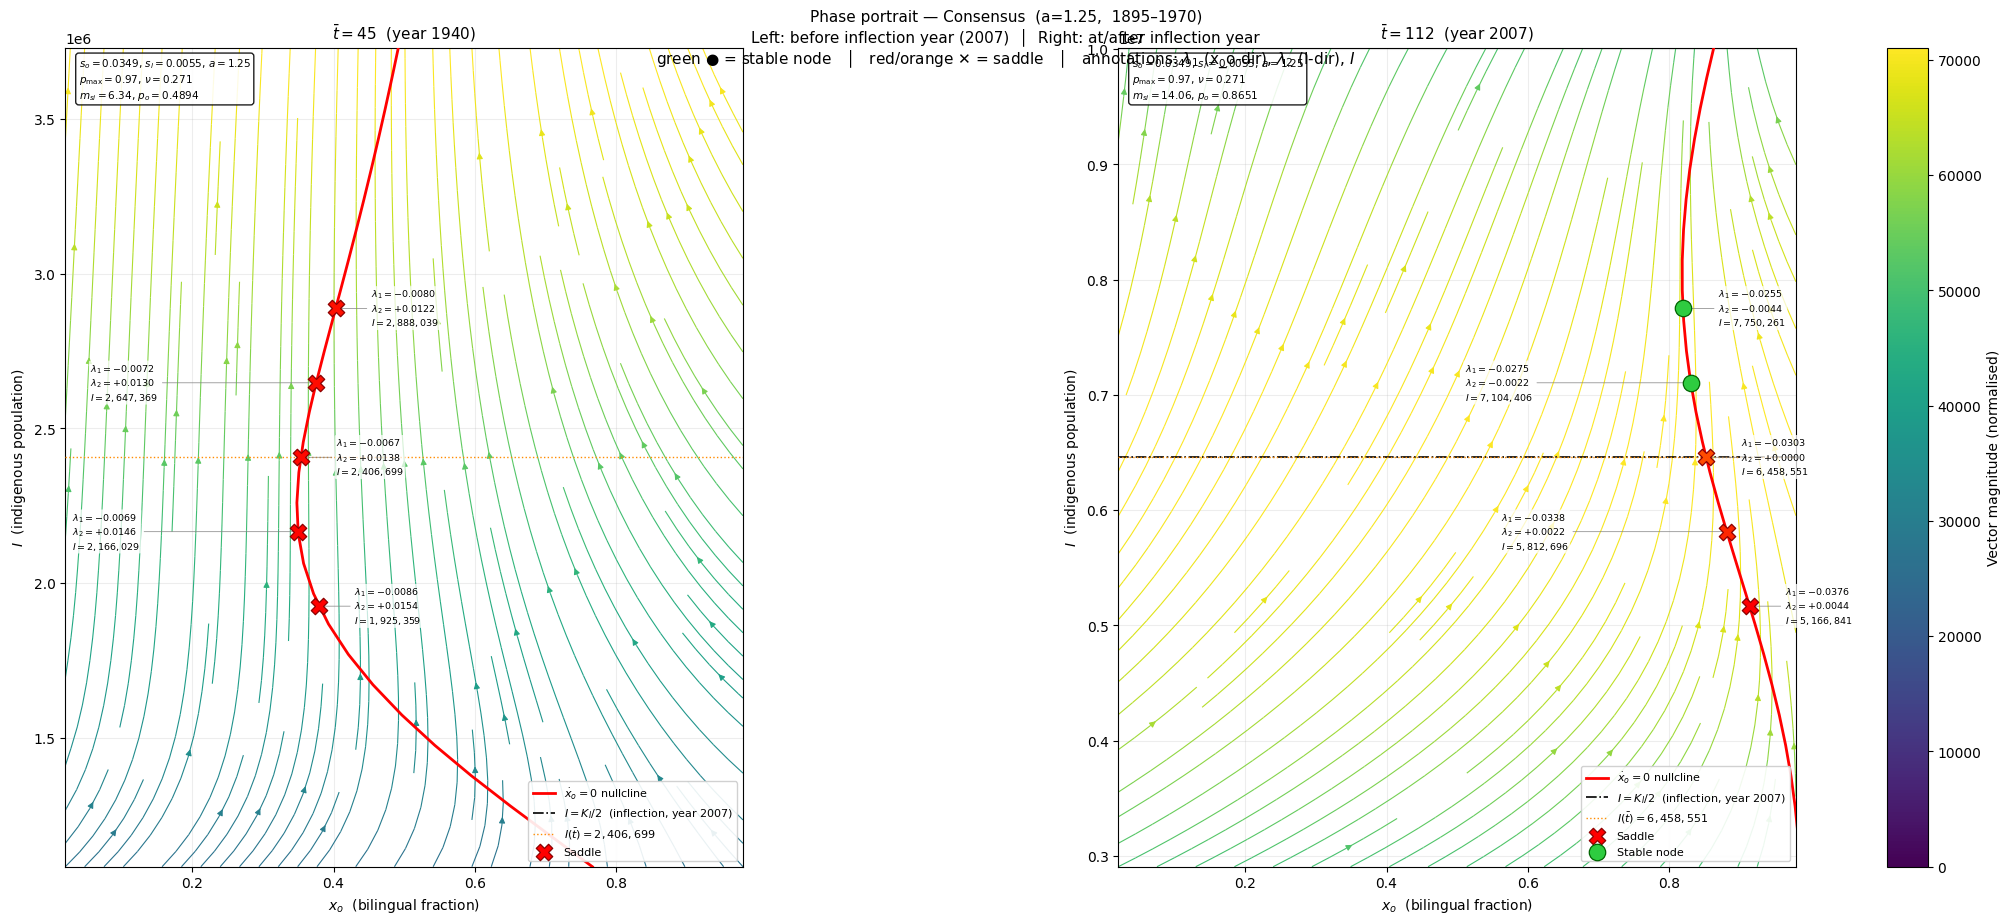

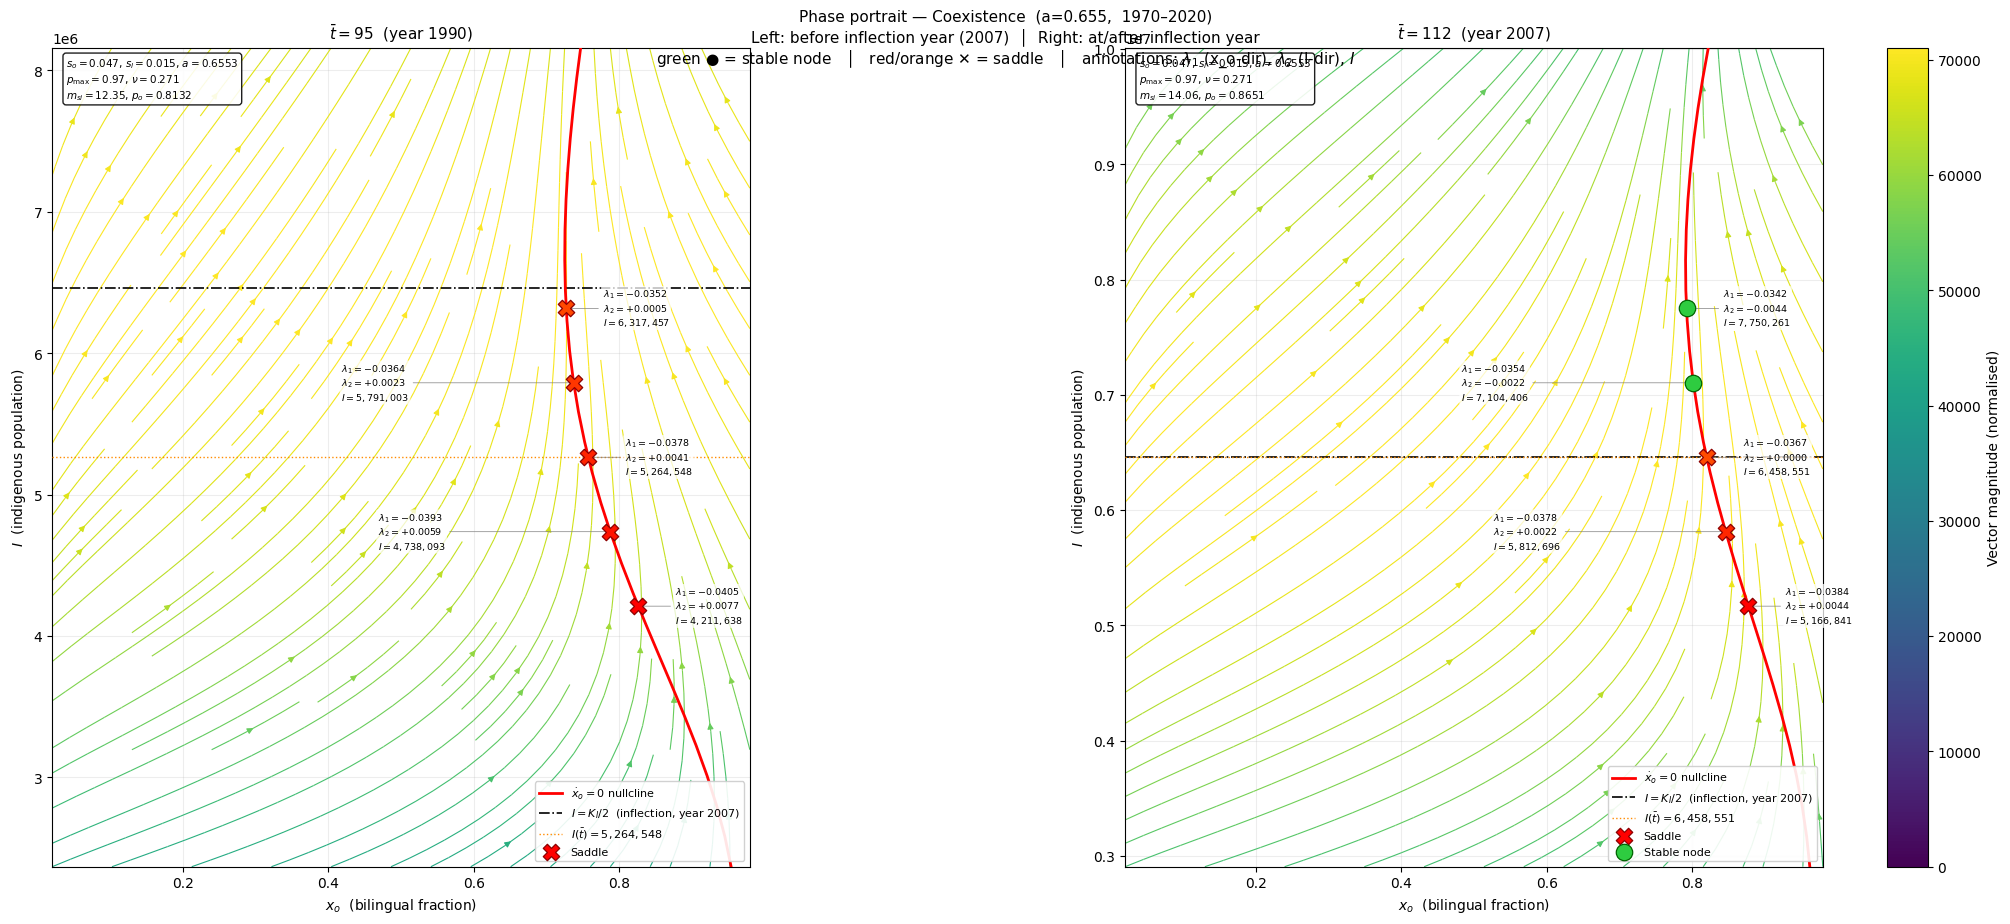

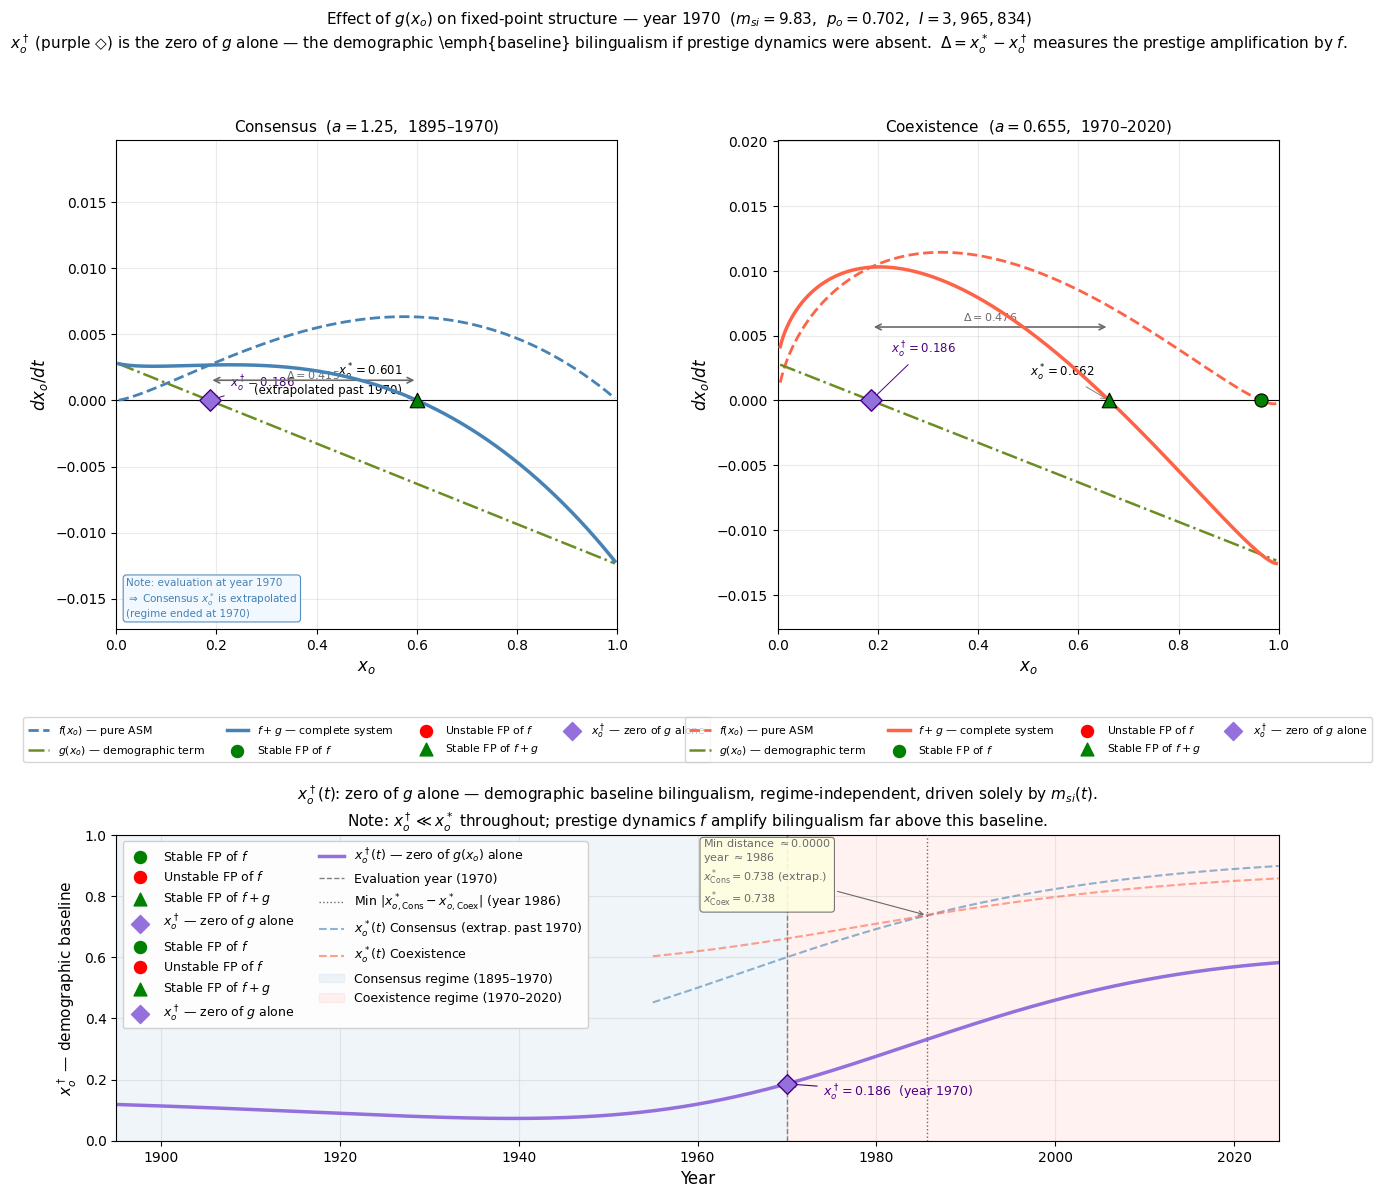

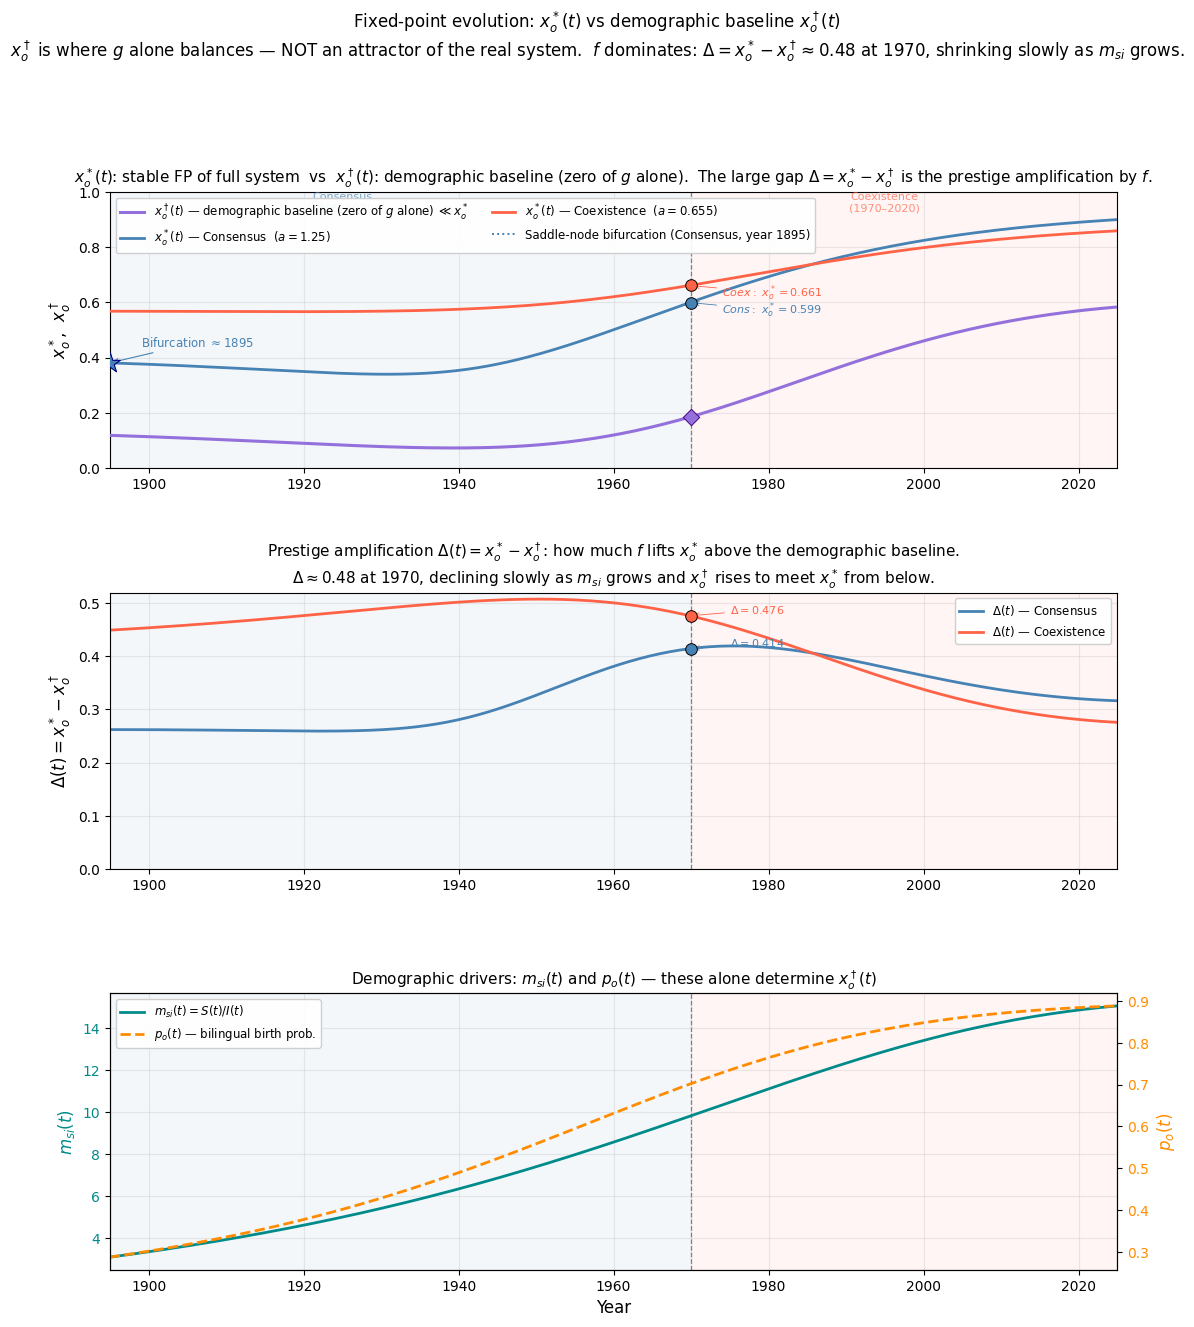

In [ ]:
"""
20 Feb 2026
transition_plots.py
====================
Generates two key diagnostic plots for the extended Abrams-Strogatz model:

PLOT 1 — Transition vector field
    Shows how the fixed point classification changes from saddle to stable node
    as the indigenous population I crosses the logistic inflection point K_I/2.
    We perturb I around year 2007 (when I ≈ K_I/2) and plot 5 fixed points
    simultaneously to visualize the red→green transition.

PLOT 2 — Dual-regime comparison
    Compares the effect of the demographic term g(x_o) in two historical periods:
      - Consensus (a=1.25, 1895-1970): g creates a stable interior fixed point
      - Coexistence (a=0.655, 1970-2020): g shifts an existing stable fixed point
    
    Shows f(x_o) [ASM alone] vs f(x_o)+g(x_o) [complete system] at year 1970.

Author: Riccardo Del Gratta, with Claude assistance
Date: February 2025
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.optimize import brentq
import warnings

# ===========================================================================
# MODEL PARAMETERS
# ===========================================================================
# These are calibrated from Mexican census data (1895-2020)

# Indigenous population logistic growth
N0_indigenous = 1012848      # Initial population at t=0 (year 1895)
K_indigenous = 12918933      # Carrying capacity
r_indigenous = 0.022         # Growth rate (yr^-1)

# Spanish population logistic growth
N0_spanish = 3117878         # Initial population at t=0
K_spanish = 165995301        # Carrying capacity
r_spanish = 0.037            # Growth rate (yr^-1)

# Bilingual birth probability parameters
A_p = 5.47                   # Sigmoid shape parameter
nu = 0.271                   # Sensitivity to m_si ratio
p_max = 0.97                 # Maximum probability

# ASM parameters for COEXISTENCE regime (1970–2020)
s_o_coex = 0.047             # Spanish prestige
s_l_coex = 0.015             # Indigenous prestige
a_coex = 0.6553              # Volatility (a < 1 → stable interior fixed point)

# ASM parameters for CONSENSUS regime (1895–1970)
s_o_cons = 0.0349            # Spanish prestige
s_l_cons = 0.0055            # Indigenous prestige
a_cons = 1.25                # Volatility (a > 1 → unstable interior, boundary attractors)

base_year = 1895             # Reference year (t=0)

# ===========================================================================
# COMPUTE THE TRANSITION YEAR (when I = K_I/2)
# ===========================================================================
# This is the year when J11 = r_I(1 - 2I/K_I) changes sign from + to -.
# It's purely demographic — the inflection point of the logistic curve for I(t).

T_CROSS = brentq(
    # This anonymous function computes I(t) - K_I/2
    # We're finding the time t where this equals zero
    lambda t: K_indigenous / (1 + ((K_indigenous-N0_indigenous)/N0_indigenous)
                               * np.exp(-r_indigenous*t)) - K_indigenous/2,
    0, 300  # Search between t=0 and t=300 years
)
YEAR_CROSS = base_year + T_CROSS  # Convert to calendar year


# ===========================================================================
# CORE MATHEMATICAL FUNCTIONS
# ===========================================================================

def logistic(t, K, r, N0):
    """
    Standard logistic growth function: N(t) = K / (1 + C*exp(-rt))
    where C = (K-N0)/N0 is determined by the initial condition.
    
    Parameters
    ----------
    t : float
        Time since base_year (years)
    K : float
        Carrying capacity (maximum population)
    r : float
        Growth rate (yr^-1)
    N0 : float
        Initial population at t=0
        
    Returns
    -------
    float
        Population at time t
        
    Notes
    -----
    The inflection point (maximum growth rate) occurs at N = K/2, which
    corresponds to time t* = (1/r) * ln(C) where C = (K-N0)/N0.
    """
    return K / (1 + ((K-N0)/N0)*np.exp(-r*t))


def p_o_func(m):
    """
    Probability that a newborn indigenous individual is bilingual.
    
    This is a sigmoid function of the Spanish-to-indigenous ratio m_si = S/I.
    As m_si increases (more Spanish speakers per indigenous speaker), the
    probability of being born bilingual increases, saturating at p_max.
    
    Parameters
    ----------
    m : float
        Spanish-to-indigenous ratio m_si = S(t)/I(t)
        
    Returns
    -------
    float
        Probability p_o ∈ (0, p_max)
        
    Formula
    -------
    p_o(m) = p_max / (1 + A * exp(-ν * m))
    
    This is a logistic (sigmoid) function:
    - When m → 0 (few Spanish speakers): p_o → 0
    - When m → ∞ (many Spanish speakers): p_o → p_max
    - The parameter ν controls how sensitive p_o is to changes in m
    """
    return p_max / (1 + A_p*np.exp(-nu*m))


def f_func(x_o, s_o, s_l, a):
    """
    Abrams-Strogatz prestige function.
    
    This encodes linguistic conversions (Monolingual ↔ Bilingual) driven by
    prestige differences. It's the "internal dynamics" of the ASM model,
    evaluated at constant population.
    
    Parameters
    ----------
    x_o : float or array
        Bilingual fraction of indigenous population (0 ≤ x_o ≤ 1)
    s_o : float
        Prestige of Spanish language
    s_l : float
        Prestige of indigenous language
    a : float
        Volatility parameter
        
    Returns
    -------
    float or array
        Rate of change dx_o/dt from ASM dynamics alone
        
    Formula
    -------
    f(x_o) = s_o * x_o^a * (1-x_o) - s_l * (1-x_o)^a * x_o
    
    The two terms represent:
    - First term: Monolinguals (fraction 1-x_o) becoming bilingual
    - Second term: Bilinguals (fraction x_o) reverting to monolingual
    
    Fixed points occur where f(x_o) = 0:
    - Always at x_o=0 and x_o=1 (boundary fixed points)
    - Interior fixed point at x_o* = 1/(1+β) where β = (s_o/s_l)^(1/(a-1))
    
    Stability of interior fixed point:
    - If a > 1: interior is UNSTABLE (repels trajectories)
    - If a < 1: interior is STABLE (attracts trajectories)
    
    Notes
    -----
    We handle boundaries carefully to avoid power-law singularities when a < 1.
    The exponents a-1 and a-2 in the derivative can be negative, causing
    division-by-zero at x_o=0 or x_o=1.
    """
    # Scalar case (single x_o value)
    if np.ndim(x_o) == 0:
        if x_o <= 0 or x_o >= 1:
            return 0.0  # Zero at boundaries (no change possible)
        # Suppress RuntimeWarning from negative exponents
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            return s_o*(x_o**a)*(1-x_o) - s_l*((1-x_o)**a)*x_o
    
    # Array case (multiple x_o values for plotting)
    else:
        x = np.asarray(x_o, dtype=float)
        out = np.zeros_like(x)
        # Only compute where 0 < x < 1 (interior)
        mask = (x > 0) & (x < 1)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            out[mask] = s_o*(x[mask]**a)*(1-x[mask]) - s_l*((1-x[mask])**a)*x[mask]
        return out


def g_func(x_o, p, m_val, I, s_o, s_l, a):
    """
    Natural increment function: demographic contribution to dx_o/dt.
    
    This term captures the effect of population growth on the bilingual fraction.
    It has three components (derived via quotient rule):
      1. New bilingual births at rate p_o * (dI/dt)
      2. Evolution of p_o itself as m_si changes
      3. Quotient-rule correction from x_o = X_o/I
    
    Parameters
    ----------
    x_o : float
        Bilingual fraction
    p : float
        Bilingual birth probability p_o(m_si)
    m_val : float
        Spanish-to-indigenous ratio m_si = S/I
    I : float
        Indigenous population
    s_o, s_l, a : float
        ASM parameters (not used here, kept for API consistency)
        
    Returns
    -------
    float
        Contribution to dx_o/dt from demographic processes
        
    Formula
    -------
    g(x_o, I) = [p_o - x_o - p_o(1-p_o/p_max)νm_si] * r_I(1 - I/K_I)
    
    The bracket combines three effects:
    - p_o: injection of new bilingual births
    - -x_o: quotient rule correction (denominator I growing)
    - -p_o(1-p_o/p_max)νm_si: evolution of p_o as I changes
    
    The factor r_I(1-I/K_I) is dI/dt / I (logistic growth rate per capita).
    """
    # The bracket [p_o - x_o - ...]
    bracket = p - x_o - p*(1-p/p_max)*nu*m_val
    
    # Logistic growth factor: (1/I) * dI/dt = r_I(1 - I/K_I)
    logistic_factor = r_indigenous*(1 - I/K_indigenous)
    
    return bracket * logistic_factor


def rhs(x_o, I, S, s_o, s_l, a):
    """
    Full right-hand side of the extended model equation.
    
    This computes dx_o/dt = f(x_o) + g(x_o, I, S) for given (x_o, I, S).
    
    Parameters
    ----------
    x_o : float
        Bilingual fraction
    I : float
        Indigenous population
    S : float
        Spanish population (held fixed in quasi-static approximation)
    s_o, s_l, a : float
        ASM parameters for the chosen regime
        
    Returns
    -------
    float
        Total rate of change dx_o/dt
        
    Notes
    -----
    Fixed points of the system satisfy rhs(x_o*, I, S) = 0.
    The stability is determined by the Jacobian eigenvalues:
      λ₁ = ∂rhs/∂x_o = J00  (x_o-direction)
      λ₂ = ∂(dI/dt)/∂I = J11 = r_I(1 - 2I/K_I)  (I-direction)
    """
    # Compute derived quantities
    m_val = S/I if I > 0 else np.inf
    p = p_o_func(m_val)
    
    # Sum ASM term + demographic term
    return f_func(x_o, s_o, s_l, a) + g_func(x_o, p, m_val, I, s_o, s_l, a)


def find_fp(I_val, S_val, s_o, s_l, a, n=3000):
    """
    Find all fixed points x_o* at given (I, S) values.
    
    Strategy: scan for sign changes, then refine with Brent's method.
    This is robust even when the function has multiple roots or nearly
    touches zero without crossing.
    
    Parameters
    ----------
    I_val, S_val : float
        Population values at which to find fixed points
    s_o, s_l, a : float
        ASM parameters
    n : int
        Number of scan points (higher = more reliable root detection)
        
    Returns
    -------
    list of float
        All fixed points x_o* ∈ (0,1) where rhs(x_o*, I_val, S_val) = 0
        
    Algorithm
    ---------
    1. Evaluate rhs on a dense grid [0.005, 0.995]
    2. Find intervals where sign changes (indicates a root)
    3. For each sign change, use Brent's method to refine the root
    
    Why Brent's method?
    - Guaranteed convergence when bracketed by sign change
    - No need for derivative (unlike Newton)
    - Robust to singularities at boundaries
    """
    # Dense scan grid
    xs = np.linspace(0.005, 0.995, n)
    
    # Evaluate rhs at all grid points
    vals = np.array([rhs(x, I_val, S_val, s_o, s_l, a) for x in xs])
    
    # Find where sign changes (indicates root between consecutive points)
    sign_changes = np.where(np.diff(np.sign(vals)))[0]
    
    roots = []
    for idx in sign_changes:
        try:
            # Brent's method: finds root in interval [xs[idx], xs[idx+1]]
            xr = brentq(
                lambda x: rhs(x, I_val, S_val, s_o, s_l, a),
                xs[idx], xs[idx+1],
                xtol=1e-10  # Tolerance: root accuracy to 10 decimal places
            )
            roots.append(xr)
        except Exception:
            # If Brent fails (shouldn't happen with sign change), skip
            pass
    
    return roots


def classify(x_o, I_val, S_val, s_o, s_l, a, eps=1e-6):
    """
    Classify a fixed point by computing J00 and J11.
    
    The Jacobian of the system is upper-triangular:
    
        J = [ J00  J01 ]
            [  0   J11 ]
    
    Eigenvalues are λ₁=J00 (x_o direction) and λ₂=J11 (I direction).
    
    Classification:
      - Both negative → Stable node (attracts in all directions)
      - One negative, one positive → Saddle (attracts in one dir, repels in other)
      - Both positive → Unstable node (repels in all directions)
    
    Parameters
    ----------
    x_o : float
        Fixed point x_o-coordinate
    I_val, S_val : float
        Population values at fixed point
    s_o, s_l, a : float
        ASM parameters
    eps : float
        Finite difference step size
        
    Returns
    -------
    fully_stable : bool
        True if stable node (both eigenvalues negative)
    saddle : bool
        True if saddle (eigenvalues of opposite signs)
    J00 : float
        Eigenvalue in x_o direction
    J11 : float
        Eigenvalue in I direction
        
    Notes
    -----
    We compute J00 numerically because the analytical derivative has
    power-law singularities when a < 1.
    
    J11 is computed analytically from the logistic equation:
        dI/dt = r_I * I * (1 - I/K_I)
        ⟹ ∂(dI/dt)/∂I = r_I(1 - 2I/K_I)
    
    This changes sign at I = K_I/2 (the logistic inflection point).
    """
    # Compute derived quantities at the fixed point
    m_val = S_val/I_val
    p = p_o_func(m_val)
    
    # --- Compute J00 numerically using centered finite differences ---
    # J00 = ∂rhs/∂x_o evaluated at (x_o, I_val, S_val)
    
    # Perturb x_o by ±eps, staying away from boundaries
    xp = min(x_o + eps, 0.995)
    xm = max(x_o - eps, 0.005)
    
    # Centered difference: (f(x+h) - f(x-h)) / (2h)
    J00 = (rhs(xp, I_val, S_val, s_o, s_l, a) 
           - rhs(xm, I_val, S_val, s_o, s_l, a)) / (xp - xm)
    
    # --- Compute J11 analytically ---
    # J11 = ∂(dI/dt)/∂I = r_I - 2*r_I*I/K_I = r_I(1 - 2I/K_I)
    J11 = r_indigenous*(1 - 2*I_val/K_indigenous)
    
    # --- Classify based on eigenvalue signs ---
    fully_stable = (J00 < 0) and (J11 < 0)  # Both attracting
    saddle = (J00 < 0) and (J11 > 0)         # One attracting, one repelling
    
    return fully_stable, saddle, J00, J11


# ===========================================================================
# PLOT 1 — TRANSITION VECTOR FIELD (two-panel: before / after 2007)
# ===========================================================================

def _draw_one_phase_portrait(ax, t_bar, s_o, s_l, a,
                              n_I_pts=5, delta_frac=0.20,
                              nx=28, nI=28, I_margin=0.55):
    """
    Draw a single phase-portrait panel on `ax` for the given snapshot time
    and regime parameters.

    This is the workhorse called twice by make_transition_panel() to build
    the before/after figure. It is not meant to be called directly.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes on which to draw.
    t_bar : float
        Snapshot time in years since base_year.
    s_o, s_l, a : float
        Regime-specific ASM parameters.
    n_I_pts : int
        Number of perturbed I values (default 5).
    delta_frac : float
        Half-width of I perturbation as fraction of I(t_bar).
    nx, nI : int
        Streamplot grid resolution.
    I_margin : float
        Vertical extent of plot as fraction of I(t_bar).

    Returns
    -------
    mag : 2-D ndarray
        Vector-magnitude array (used by the caller to build the colorbar).
    mag95 : float
        95th-percentile magnitude (normalisation reference).
    """
    year_bar = int(base_year + t_bar)

    # Population values at this snapshot
    I_center = logistic(t_bar, K_indigenous, r_indigenous, N0_indigenous)
    S_bar    = logistic(t_bar, K_spanish,    r_spanish,    N0_spanish)

    # ----- Perturbed I probe points -----
    delta   = delta_frac * I_center
    I_probe = np.linspace(I_center - delta, I_center + delta, n_I_pts)

    # ----- Find + classify fixed points -----
    fp_data = []
    for I_val in I_probe:
        if I_val <= 0:
            continue
        # Both find_fp and classify use the SAME regime parameters
        roots = find_fp(I_val, S_bar, s_o, s_l, a)
        for xr in roots:
            fs, saddle, J00, J11 = classify(xr, I_val, S_bar, s_o, s_l, a)
            fp_data.append({'x_o': xr, 'I': I_val,
                            'J00': J00, 'J11': J11,
                            'stable': fs, 'saddle': saddle})

    # ----- Vector field grid -----
    x_arr = np.linspace(0.02, 0.98, nx)
    I_lo  = max(I_center*(1 - I_margin), 0.01*K_indigenous)
    I_hi  = min(I_center*(1 + I_margin), 0.999*K_indigenous)
    I_arr = np.linspace(I_lo, I_hi, nI)

    X, IG = np.meshgrid(x_arr, I_arr)
    U = np.zeros_like(X)
    V = np.zeros_like(X)
    for i in range(nI):
        for j in range(nx):
            U[i, j] = rhs(X[i, j], IG[i, j], S_bar, s_o, s_l, a)
            V[i, j] = r_indigenous * IG[i, j] * (1 - IG[i, j]/K_indigenous)

    mag   = np.sqrt(U**2 + V**2)
    mag95 = np.percentile(mag[mag > 0], 95) if np.any(mag > 0) else 1.0
    Un = np.where(mag > 0, U/mag95, 0)
    Vn = np.where(mag > 0, V/mag95, 0)

    # ----- Nullcline (dx_o/dt = 0) -----
    nullcline = []
    for I_val in I_arr:
        if I_val <= 0:
            continue
        xs_nc  = np.linspace(0.005, 0.995, 3000)
        vals_nc = np.array([rhs(x, I_val, S_bar, s_o, s_l, a) for x in xs_nc])
        sc_nc  = np.where(np.diff(np.sign(vals_nc)))[0]
        for idx in sc_nc:
            try:
                xn = brentq(lambda x: rhs(x, I_val, S_bar, s_o, s_l, a),
                            xs_nc[idx], xs_nc[idx+1], xtol=1e-8)
                nullcline.append((xn, I_val))
            except Exception:
                pass

    # ----- Streamplot -----
    norm = mcolors.Normalize(vmin=0, vmax=mag95)
    ax.streamplot(X, IG, Un, Vn, density=1.2,
                  color=mag, cmap='viridis', norm=norm,
                  linewidth=0.8, arrowsize=0.9)

    # ----- Nullcline curve -----
    if nullcline:
        nc_x, nc_I = zip(*sorted(nullcline, key=lambda p: p[1]))
        ax.plot(nc_x, nc_I, color='red', lw=2.0, zorder=4,
                label=r'$\dot{x}_o = 0$ nullcline')

    # ----- Reference lines -----
    ax.axhline(K_indigenous/2, color='black', lw=1.2, ls='-.',
               label=f'$I = K_I/2$  (inflection, year {YEAR_CROSS:.0f})',
               zorder=3)
    ax.axhline(I_center, color='darkorange', lw=1.0, ls=':',
               label=fr'$I(\bar{{t}}) = {I_center:,.0f}$', zorder=3)

    # ----- Fixed points (colour-coded) -----
    J11_vals = [d['J11'] for d in fp_data]
    J11_max  = max(abs(v) for v in J11_vals) if J11_vals else 1.0

    plotted_stable = plotted_saddle = False
    for d in fp_data:
        if d['stable']:
            clr    = '#2ecc40'
            marker = 'o'
            edge   = 'darkgreen'
            lbl    = 'Stable node' if not plotted_stable else '_'
            plotted_stable = True
        else:
            intensity = min(d['J11']/J11_max, 1.0) if J11_max > 0 else 1.0
            clr    = (1.0, max(0, 0.3*(1-intensity)), 0.0)
            marker = 'X'
            edge   = 'darkred'
            lbl    = 'Saddle' if not plotted_saddle else '_'
            plotted_saddle = True
        ax.scatter(d['x_o'], d['I'], color=clr, marker=marker,
                   s=140, zorder=6, edgecolors=edge, linewidths=0.9, label=lbl)

    # ----- Annotations: λ₁, λ₂, I -----
    # We alternate offset direction (right / left) to avoid overlaps
    for k, d in enumerate(fp_data):
        s1 = '+' if d['J00'] >= 0 else ''
        s2 = '+' if d['J11'] >= 0 else ''
        txt = (fr"$\lambda_1={s1}{d['J00']:.4f}$"
               "\n"
               fr"$\lambda_2={s2}{d['J11']:.4f}$"
               "\n"
               fr"$I={d['I']:,.0f}$")

        # Alternate: even indices offset to the right, odd to the left
        x_offset = +0.05 if k % 2 == 0 else -0.32
        ax.annotate(txt,
                    xy=(d['x_o'], d['I']),
                    xytext=(d['x_o'] + x_offset, d['I']),
                    fontsize=6.8, color='black',
                    va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              alpha=0.75, lw=0),
                    arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))

    # ----- Parameter info box (top-left) -----
    m_bar = S_bar / I_center
    p_bar = p_o_func(m_bar)
    param_txt = (f'$s_o={s_o}$, $s_l={s_l}$, $a={a}$\n'
                 f'$p_{{\\max}}={p_max}$, $\\nu={nu}$\n'
                 f'$m_{{si}}={m_bar:.2f}$, $p_o={p_bar:.4f}$')
    ax.text(0.02, 0.99, param_txt, transform=ax.transAxes,
            fontsize=7.5, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.88))

    # ----- Axes labels + title -----
    ax.set_xlabel(r'$x_o$  (bilingual fraction)', fontsize=10)
    ax.set_ylabel(r'$I$  (indigenous population)', fontsize=10)
    ax.set_title(f'$\\bar{{t}}={t_bar:.0f}$  (year {year_bar})', fontsize=11)
    ax.set_xlim(x_arr.min(), x_arr.max())
    ax.set_ylim(I_arr.min(), I_arr.max())
    ax.grid(alpha=0.22)
    ax.legend(fontsize=8, loc='lower right', framealpha=0.9)

    return mag, mag95


def make_transition_panel(t_before, t_after, s_o, s_l, a, regime_label,
                          regime_prefix='regime',
                          n_I_pts=5, delta_frac=0.20,
                          nx=28, nI=28, I_margin=0.55):
    """
    Create a two-panel figure showing the saddle → stable-node transition
    for one regime, comparing a snapshot BEFORE and AFTER year 2007
    (when I crosses K_I/2 and J11 changes sign).

    Each panel shows:
      - Streamplot of the (x_o, I) vector field
      - The x_o-nullcline (dx_o/dt = 0)
      - K_I/2 reference line
      - 5 perturbed fixed points with colour coding:
            green circle  → stable node  (J00<0, J11<0)
            red/orange ×  → saddle       (J00<0, J11>0)
      - Annotation per fixed point: λ₁ = J00, λ₂ = J11, and I

    BUG FIX (vs. original): find_fp and classify now both use the same
    regime parameters (s_o, s_l, a), eliminating the original mismatch
    where find_fp used consensus params but classify used coexistence params.

    Parameters
    ----------
    t_before : float
        Snapshot time (yrs since 1895) BEFORE the 2007 inflection.
        Consensus: 45 (year 1940); Coexistence: 95 (year 1990).
    t_after : float
        Snapshot time AFTER the 2007 inflection.
        Both regimes: 112 (year 2007) or later.
    s_o, s_l, a : float
        Regime-specific ASM parameters.
    regime_label : str
        Short label for the suptitle (e.g. 'Consensus  (a=1.25)').
    n_I_pts, delta_frac, nx, nI, I_margin : see _draw_one_phase_portrait.
    regime_prefix : str
        Short prefix used to name the individual subplot files.
        Each panel is saved as  {regime_prefix}_t{t_bar:.0f}.png
        e.g. 'coex' → 'coex_t95.png', 'coex_t112.png'

    Returns
    -------
    matplotlib.figure.Figure
    """
    kw = dict(s_o=s_o, s_l=s_l, a=a,
              n_I_pts=n_I_pts, delta_frac=delta_frac,
              nx=nx, nI=nI, I_margin=I_margin)

    # ------------------------------------------------------------------
    # Save each panel as a standalone figure first
    # We create a temporary single-axes figure, draw on it, save, close.
    # ------------------------------------------------------------------
    for t_bar in (t_before, t_after):
        fig_single, ax_single = plt.subplots(figsize=(11, 9),
                                             layout='constrained')
        mag_s, mag95_s = _draw_one_phase_portrait(ax_single, t_bar, **kw)

        # Colorbar for the standalone figure
        norm_s = mcolors.Normalize(vmin=0, vmax=mag95_s)
        sm_s   = cm.ScalarMappable(cmap='viridis', norm=norm_s)
        sm_s.set_array([])
        fig_single.colorbar(sm_s, ax=ax_single,
                            label='Vector magnitude (normalised)', fraction=0.046)

        fig_single.suptitle(
            f'Phase portrait — {regime_label}\n'
            f'green ● = stable node   │   red/orange ✕ = saddle   '
            f'│   $\\lambda_1$ (x_o-dir), $\\lambda_2$ (I-dir), $I$',
            fontsize=11
        )

        fname = f"{regime_prefix}_t{t_bar:.0f}.png"
        fig_single.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"        · Saved subplot: {fname}")
        plt.close(fig_single)

    # ------------------------------------------------------------------
    # Now build the combined two-panel figure
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(20, 9),
                              gridspec_kw={'wspace': 0.32},
                              layout='constrained')

    # Left panel  — before 2007
    mag_l, mag95_l = _draw_one_phase_portrait(axes[0], t_before, **kw)

    # Right panel — after 2007
    mag_r, mag95_r = _draw_one_phase_portrait(axes[1], t_after, **kw)

    # Shared colorbar (use the larger of the two magnitude ranges)
    global_mag95 = max(mag95_l, mag95_r)
    norm_cb = mcolors.Normalize(vmin=0, vmax=global_mag95)
    sm = cm.ScalarMappable(cmap='viridis', norm=norm_cb)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label('Vector magnitude (normalised)', fontsize=10)

    fig.suptitle(
        f'Phase portrait — {regime_label}\n'
        f'Left: before inflection year ({YEAR_CROSS:.0f})  '
        f'│  Right: at/after inflection year\n'
        f'green ● = stable node   │   red/orange ✕ = saddle   '
        f'│   annotations: $\\lambda_1$ (x_o-dir), $\\lambda_2$ (I-dir), $I$',
        fontsize=11, y=1.01
    )
    return fig


# ===========================================================================
# PLOT 2 — DUAL-REGIME f(x_o) AND f+g COMPARISON
# (with g-only demographic fixed point analysis)
# ===========================================================================

def g_only_func(x_o, I_val, S_val):
    """
    Evaluate g(x_o) with f set to zero, i.e. the purely demographic term.

    The zero of this function, x_o^†, is the bilingual fraction at which
    demographic processes alone would be in balance — i.e. where new
    bilingual births exactly offset the dilution effect from population
    growth.  It is determined entirely by m_si = S/I and p_o(m_si), and
    is completely independent of the ASM parameters s_o, s_l, a.

    Physical interpretation of x_o^†
    ----------------------------------
    x_o^† is NOT close to x_o* in general.  Numerically (e.g. year 1970):
      x_o^† ≈ 0.186   (where g alone balances)
      x_o*  ≈ 0.662   (stable FP of the full system f + g)
      Δ     ≈ 0.476   (prestige amplification by f)

    The large gap Δ = |x_o* - x_o^†| measures how much f (ASM prestige
    dynamics) lifts x_o* above the purely demographic baseline.  f is
    dominant throughout the historical record; g alone would produce far
    less bilingualism than is observed.  Over time, as m_si grows, x_o^†
    rises and Δ shrinks — but remains substantial (≈ 0.28 by 2020).

    Stability of x_o^†
    -------------------
    g'(x_o^†) < 0: the zero is a stable fixed point *of g alone*.  g
    pushes toward x_o^† from both sides.  However, f dominates and places
    x_o* far above x_o^†; x_o^† is never approached by the real system.

    Parameters
    ----------
    x_o   : float  bilingual fraction
    I_val : float  indigenous population
    S_val : float  Spanish population

    Returns
    -------
    float  value of g(x_o) at these populations
    """
    m_val = S_val / I_val
    p     = p_o_func(m_val)
    # g_func with dummy s_o, s_l, a (unused inside g_func)
    return g_func(x_o, p, m_val, I_val, 0, 0, 1)


def demographic_fp(I_val, S_val):
    """
    Compute x_o^† analytically: the zero of g alone.

        x_o^† = p_o * [1 - (1 - p_o/p_max) * ν * m_si]

    This is the bilingual fraction at which demographic processes alone
    balance: new bilingual births (rate p_o * dI/dt) exactly offset the
    dilution from population growth (quotient-rule correction).

    Physical meaning and scale
    --------------------------
    x_o^† is the demographic *baseline* — what bilingualism would be if
    prestige dynamics (f) were absent.  It is NOT close to x_o* of the
    real system.  The prestige term f lifts x_o* far above x_o^†:

      Year  |  x_o^†  |  x_o* (Coex)  |  Δ = x_o* - x_o^†
      ------+---------+---------------+-------------------
      1970  |  0.186  |    0.662      |    0.476
      1990  |  0.372  |    0.758      |    0.386
      2010  |  0.525  |    0.828      |    0.303
      2020  |  0.569  |    0.850      |    0.281

    The gap Δ measures the prestige amplification of bilingualism.
    It is large throughout the historical record and shrinks only slowly
    as m_si grows and x_o^† rises to meet x_o* from below.

    x_o^† is regime-independent (depends only on m_si, A_p, ν, p_max),
    so both Consensus and Coexistence share the same x_o^† at any t.

    Parameters
    ----------
    I_val, S_val : float  populations

    Returns
    -------
    float  x_o^† ∈ (0, 1), or nan if outside that interval
    """
    m   = S_val / I_val
    p   = p_o_func(m)
    xd  = p * (1.0 - (1.0 - p/p_max) * nu * m)
    return xd if 0 < xd < 1 else np.nan


def make_dual_regime_plot(t_boundary=75.0):
    """
    Compare ASM alone vs complete system in both regimes, and show the
    purely demographic fixed point x_o^† (zero of g alone) to explain
    why the two regimes share nearly the same x_o* at t=1970.

    Layout
    ------
    Top row  (2 panels): Consensus (left) and Coexistence (right)
        Each panel shows:
          · f(x_o)         — dashed, regime colour
          · g(x_o)         — dashed, olive green  (NEW)
          · f(x_o)+g(x_o)  — solid,  regime colour
          · ○  fixed points of f alone  (green=stable, red=unstable)
          · △  fixed points of f+g      (green=stable, red=unstable)
          · ◇  x_o^†  (zero of g alone) — purple diamond  (NEW)
          · Δ = |x_o* − x_o^†| annotation  (NEW)

    Bottom panel: x_o^†(t) over the full 1895-2025 range  (NEW)
        Shows that x_o^† is regime-independent and driven purely by m_si(t).
        The vertical line at t_boundary marks the evaluation year.

    Parameters
    ----------
    t_boundary : float
        Time at which the top panels are evaluated (default 75 = year 1970).

    Returns
    -------
    matplotlib.figure.Figure
    """
    # ---- Populations and derived quantities at t_boundary ----
    I_t = logistic(t_boundary, K_indigenous, r_indigenous, N0_indigenous)
    S_t = logistic(t_boundary, K_spanish,    r_spanish,    N0_spanish)
    m_t = S_t / I_t
    p_t = p_o_func(m_t)

    # ---- Purely demographic fixed point at t_boundary ----
    xd_t = demographic_fp(I_t, S_t)

    # ---- Dense x_o grid ----
    xs = np.linspace(0.005, 0.995, 4000)

    # ---- g(x_o) values (regime-independent) ----
    g_vals = np.array([g_only_func(x, I_t, S_t) for x in xs])

    # ---- Regime definitions ----
    # NOTE: t_boundary=75 corresponds to year 1970, the last year of the
    # Consensus regime.  The Consensus panel therefore shows an EXTRAPOLATED
    # value of x_o*: the Consensus parameters (a=1.25) were no longer active
    # at that date.  The value is computed for comparison purposes only.
    regimes = [
        dict(s_o=s_o_cons, s_l=s_l_cons, a=a_cons,
             label='Consensus  ($a=1.25$,  1895–1970)',
             color='steelblue',
             is_consensus=True),
        dict(s_o=s_o_coex, s_l=s_l_coex, a=a_coex,
             label='Coexistence  ($a=0.655$,  1970–2020)',
             color='tomato',
             is_consensus=False),
    ]

    # ---- Pre-compute minimum-distance year between the two regime curves ----
    # We scan t in [60, 130] (years 1955-2025) and find where
    # |x*_cons(t) - x*_coex(t)| is minimised.
    # Both curves are computed even outside their "active" historical range.
    _t_scan  = np.linspace(60, 130, 4000)
    _diffs   = []
    for _t in _t_scan:
        _I = logistic(_t, K_indigenous, r_indigenous, N0_indigenous)
        _S = logistic(_t, K_spanish,    r_spanish,    N0_spanish)
        _xc = _xx = np.nan
        for _r in find_fp(_I, _S, s_o_cons, s_l_cons, a_cons):
            _sl = (rhs(_r+1e-5,_I,_S,s_o_cons,s_l_cons,a_cons)
                  -rhs(_r-1e-5,_I,_S,s_o_cons,s_l_cons,a_cons))/2e-5
            if _sl < 0: _xc = _r; break
        for _r in find_fp(_I, _S, s_o_coex, s_l_coex, a_coex):
            _sl = (rhs(_r+1e-5,_I,_S,s_o_coex,s_l_coex,a_coex)
                  -rhs(_r-1e-5,_I,_S,s_o_coex,s_l_coex,a_coex))/2e-5
            if _sl < 0: _xx = _r; break
        if np.isfinite(_xc) and np.isfinite(_xx):
            _diffs.append((_t, abs(_xc - _xx), _xc, _xx))
    _idx_min  = int(np.argmin([d[1] for d in _diffs]))
    _t_mindist, _d_mindist, _xc_mindist, _xx_mindist = _diffs[_idx_min]
    _year_mindist = base_year + _t_mindist

    # ====================================================================
    # Figure layout: 2 top panels + 1 wide bottom panel
    # ====================================================================
    fig = plt.figure(figsize=(15, 13))
    gs  = fig.add_gridspec(2, 2,
                           height_ratios=[1.6, 1.0],
                           hspace=0.52, wspace=0.32)

    ax_top  = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
    ax_bot  = fig.add_subplot(gs[1, :])   # spans both columns

    # ====================================================================
    # TOP PANELS — one per regime
    # ====================================================================
    for ax, reg in zip(ax_top, regimes):
        s_o, s_l, a = reg['s_o'], reg['s_l'], reg['a']
        color = reg['color']
        is_consensus = reg['is_consensus']

        f_vals  = f_func(xs, s_o, s_l, a)
        fg_vals = np.array([rhs(x, I_t, S_t, s_o, s_l, a) for x in xs])

        # Reference lines
        ax.axhline(0, color='k', lw=0.8, zorder=2)
        ax.axvline(0, color='grey', lw=0.4, ls=':', zorder=1)
        ax.axvline(1, color='grey', lw=0.4, ls=':', zorder=1)

        # f(x_o)  — pure ASM
        ax.plot(xs, f_vals,  color=color,     lw=2.0, ls='--', zorder=3,
                label=r'$f(x_o)$ — pure ASM')

        # g(x_o)  — demographic term (same curve in both panels)
        ax.plot(xs, g_vals,  color='olivedrab', lw=1.8, ls='-.', zorder=3,
                label=r'$g(x_o)$ — demographic term')

        # f+g  — complete system
        ax.plot(xs, fg_vals, color=color,     lw=2.5, ls='-',  zorder=4,
                label=r'$f+g$ — complete system')

        # ---- Fixed points of f alone ----
        sc_f = np.where(np.diff(np.sign(f_vals)))[0]
        for idx in sc_f:
            try:
                xr = brentq(lambda x: float(f_func(x, s_o, s_l, a)),
                            xs[idx], xs[idx+1])
                slope = (float(f_func(xr+1e-5, s_o, s_l, a))
                        -float(f_func(xr-1e-5, s_o, s_l, a))) / 2e-5
                fc = 'green' if slope < 0 else 'red'
                ax.scatter(xr, 0, color=fc, marker='o', s=90,
                           edgecolors='k', lw=0.8, zorder=5)
            except Exception:
                pass

        # ---- Fixed points of f+g ----
        fp_fg_list = []
        sc_fg = np.where(np.diff(np.sign(fg_vals)))[0]
        for idx in sc_fg:
            try:
                xr = brentq(lambda x: rhs(x, I_t, S_t, s_o, s_l, a),
                            xs[idx], xs[idx+1])
                slope = (rhs(xr+1e-5, I_t, S_t, s_o, s_l, a)
                        -rhs(xr-1e-5, I_t, S_t, s_o, s_l, a)) / 2e-5
                fc = 'green' if slope < 0 else 'red'
                ax.scatter(xr, 0, color=fc, marker='^', s=110,
                           edgecolors='k', lw=0.8, zorder=5)
                fp_fg_list.append((xr, fc))

                # x_o* label — with extrapolation warning for Consensus
                y_lbl = max(fg_vals) * 0.18
                extrap_note = '\n(extrapolated past 1970)' if is_consensus else ''
                ax.annotate(fr'$x_o^*={xr:.3f}${extrap_note}',
                            xy=(xr, 0),
                            xytext=(xr - 0.03, y_lbl),
                            fontsize=8.5, color='black', ha='right',
                            arrowprops=dict(arrowstyle='->', color='grey', lw=0.7))
            except Exception:
                pass

        # ---- x_o^†  — zero of g alone ----
        if not np.isnan(xd_t):
            ax.scatter(xd_t, 0, color='mediumpurple', marker='D', s=120,
                       edgecolors='indigo', lw=1.0, zorder=6,
                       label=fr'$x_o^\dagger={xd_t:.3f}$ — zero of $g$ alone')

            # Annotate x_o^†
            ax.annotate(fr'$x_o^\dagger={xd_t:.3f}$',
                        xy=(xd_t, 0),
                        xytext=(xd_t + 0.04, max(fg_vals) * 0.35),
                        fontsize=8.5, color='indigo',
                        arrowprops=dict(arrowstyle='->', color='indigo', lw=0.7))

            # Δ = |x_o* − x_o^†| for every stable fixed point of f+g
            for xr, fc in fp_fg_list:
                if fc == 'green':
                    delta_x = abs(xr - xd_t)
                    y_mid   = max(fg_vals) * 0.55
                    # horizontal bracket arrow
                    ax.annotate('',
                                xy=(xr,    y_mid),
                                xytext=(xd_t, y_mid),
                                arrowprops=dict(arrowstyle='<->', color='dimgray',
                                                lw=1.2))
                    ax.text((xr + xd_t)/2, y_mid * 1.08,
                            fr'$\Delta={delta_x:.3f}$',
                            fontsize=8, ha='center', color='dimgray')

        # ---- Extrapolation warning box (Consensus panel only) ----
        if is_consensus:
            ax.text(0.02, 0.02,
                    'Note: evaluation at year 1970\n'
                    r'$\Rightarrow$ Consensus $x_o^*$ is extrapolated' '\n'
                    '(regime ended at 1970)',
                    transform=ax.transAxes,
                    fontsize=7.5, color='steelblue', va='bottom', ha='left',
                    bbox=dict(boxstyle='round,pad=0.3', fc='aliceblue',
                              ec='steelblue', alpha=0.90, lw=0.8))

        # y-axis limits: a little breathing room above/below
        y_span = max(abs(fg_vals.max()), abs(fg_vals.min()),
                     abs(g_vals.max()),  abs(g_vals.min()))
        ax.set_ylim(-y_span * 1.4, y_span * 1.6)

        ax.set_xlabel(r'$x_o$', fontsize=12)
        ax.set_ylabel(r'$dx_o/dt$', fontsize=12)
        ax.set_title(reg['label'], fontsize=11)
        ax.set_xlim(0, 1)
        ax.grid(alpha=0.25)

        # Legend
        handles = [
            Line2D([0],[0], color=color,       ls='--', lw=2,
                   label=r'$f(x_o)$ — pure ASM'),
            Line2D([0],[0], color='olivedrab', ls='-.', lw=1.8,
                   label=r'$g(x_o)$ — demographic term'),
            Line2D([0],[0], color=color,       ls='-',  lw=2.5,
                   label=r'$f+g$ — complete system'),
            plt.scatter([],[], color='green',       marker='o', s=75,
                        label=r'Stable FP of $f$'),
            plt.scatter([],[], color='red',         marker='o', s=75,
                        label=r'Unstable FP of $f$'),
            plt.scatter([],[], color='green',       marker='^', s=85,
                        label=r'Stable FP of $f+g$'),
            plt.scatter([],[], color='mediumpurple',marker='D', s=85,
                        label=r'$x_o^\dagger$ — zero of $g$ alone'),
        ]
        ax.legend(handles=handles, fontsize=7.8,
                  loc='upper center', bbox_to_anchor=(0.5, -0.18),
                  ncol=4, borderaxespad=0, frameon=True)

    # ====================================================================
    # BOTTOM PANEL — x_o^†(t) over time  (regime-independent)
    # ====================================================================
    t_range  = np.linspace(0, 130, 800)          # 1895 … 2025
    year_range = base_year + t_range
    xd_series  = np.array([
        demographic_fp(
            logistic(t, K_indigenous, r_indigenous, N0_indigenous),
            logistic(t, K_spanish,    r_spanish,    N0_spanish)
        ) for t in t_range
    ])

    ax_bot.plot(year_range, xd_series, color='mediumpurple', lw=2.5,
                label=r'$x_o^\dagger(t)$ — zero of $g(x_o)$ alone')

    # Mark evaluation year
    xd_eval = demographic_fp(I_t, S_t)
    ax_bot.axvline(base_year + t_boundary, color='grey', lw=1.0, ls='--',
                   label=f'Evaluation year ({int(base_year+t_boundary)})')
    ax_bot.scatter(base_year + t_boundary, xd_eval,
                   color='mediumpurple', marker='D', s=100,
                   edgecolors='indigo', lw=1.0, zorder=5)
    ax_bot.annotate(fr'$x_o^\dagger={xd_eval:.3f}$  (year {int(base_year+t_boundary)})',
                    xy=(base_year + t_boundary, xd_eval),
                    xytext=(base_year + t_boundary + 4, xd_eval - 0.04),
                    fontsize=9, color='indigo',
                    arrowprops=dict(arrowstyle='->', color='indigo', lw=0.8))

    # ---- Mark the year of minimum distance between x*_cons and x*_coex ----
    ax_bot.axvline(_year_mindist, color='dimgray', lw=1.0, ls=':',
                   label=fr'Min $|x_{{o,\mathrm{{Cons}}}}^*-x_{{o,\mathrm{{Coex}}}}^*|$ '
                         fr'(year {_year_mindist:.0f})', zorder=4)
    ax_bot.annotate(
        fr'Min distance $\approx{_d_mindist:.4f}$' '\n'
        fr'year $\approx{_year_mindist:.0f}$' '\n'
        fr'$x^*_{{\mathrm{{Cons}}}}={_xc_mindist:.3f}$ (extrap.)' '\n'
        fr'$x^*_{{\mathrm{{Coex}}}}={_xx_mindist:.3f}$',
        xy=(_year_mindist, (_xc_mindist + _xx_mindist) / 2),
        xytext=(_year_mindist - 25, 0.78),
        fontsize=8, color='dimgray',
        arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8),
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow',
                  ec='dimgray', alpha=0.90, lw=0.8)
    )
    # Plot x*_cons and x*_coex on bottom panel for comparison
    _t_bot = np.linspace(60, 130, 800)
    _xc_bot = []; _xx_bot = []; _yr_bot = []
    for _t in _t_bot:
        _I = logistic(_t, K_indigenous, r_indigenous, N0_indigenous)
        _S = logistic(_t, K_spanish,    r_spanish,    N0_spanish)
        _xc = _xx = np.nan
        for _r in find_fp(_I, _S, s_o_cons, s_l_cons, a_cons):
            _sl = (rhs(_r+1e-5,_I,_S,s_o_cons,s_l_cons,a_cons)
                  -rhs(_r-1e-5,_I,_S,s_o_cons,s_l_cons,a_cons))/2e-5
            if _sl < 0: _xc = _r; break
        for _r in find_fp(_I, _S, s_o_coex, s_l_coex, a_coex):
            _sl = (rhs(_r+1e-5,_I,_S,s_o_coex,s_l_coex,a_coex)
                  -rhs(_r-1e-5,_I,_S,s_o_coex,s_l_coex,a_coex))/2e-5
            if _sl < 0: _xx = _r; break
        _xc_bot.append(_xc); _xx_bot.append(_xx); _yr_bot.append(base_year + _t)
    _xc_bot = np.array(_xc_bot); _xx_bot = np.array(_xx_bot)
    _yr_bot = np.array(_yr_bot)
    ax_bot.plot(_yr_bot, _xc_bot, color='steelblue', lw=1.5, ls='--', alpha=0.6,
                label=r'$x_o^*(t)$ Consensus (extrap. past 1970)')
    ax_bot.plot(_yr_bot, _xx_bot, color='tomato',    lw=1.5, ls='--', alpha=0.6,
                label=r'$x_o^*(t)$ Coexistence')

    # Regime boundary shading
    ax_bot.axvspan(1895, 1970, alpha=0.08, color='steelblue',
                   label='Consensus regime (1895–1970)')
    ax_bot.axvspan(1970, 2025, alpha=0.08, color='tomato',
                   label='Coexistence regime (1970–2020)')

    ax_bot.set_xlabel('Year', fontsize=12)
    ax_bot.set_ylabel(r'$x_o^\dagger$ — demographic baseline', fontsize=11)
    ax_bot.set_title(
        r'$x_o^\dagger(t)$: zero of $g$ alone — demographic baseline bilingualism, '
        r'regime-independent, driven solely by $m_{si}(t)$.'
        '\n'
        r'Note: $x_o^\dagger \ll x_o^*$ throughout; '
        r'prestige dynamics $f$ amplify bilingualism far above this baseline.',
        fontsize=11
    )
    ax_bot.set_xlim(year_range.min(), year_range.max())
    ax_bot.set_ylim(0, 1)
    ax_bot.grid(alpha=0.25)
    ax_bot.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.9)

    # ====================================================================
    # Overall title
    # ====================================================================
    fig.suptitle(
        f'Effect of $g(x_o)$ on fixed-point structure — '
        f'year {int(base_year+t_boundary)}  '
        f'($m_{{si}}={m_t:.2f}$,  $p_o={p_t:.3f}$,  $I={I_t:,.0f}$)\n'
        r'$x_o^\dagger$ (purple ◇) is the zero of $g$ alone — the demographic '
        r'\emph{baseline} bilingualism if prestige dynamics were absent.  '
        r'$\Delta = x_o^* - x_o^\dagger$ measures the prestige amplification by $f$.',
        fontsize=11
    )
    return fig


# ===========================================================================
# PLOT 3 — FIXED POINT EVOLUTION OVER TIME
# ===========================================================================

def make_fp_evolution_plot(t_start=0.0, t_end=130.0, n_t=300):
    """
    Track x_o*(t), x_o^†(t), and Δ(t) = |x_o* − x_o^†| over the full
    historical range for both regimes.

    This answers the question: "what happens at times other than 1970?"

    Key features shown
    ------------------
    · x_o^†(t)  — purely demographic FP, regime-independent (purple)
    · x_o*(t)   — FP of the full system f+g, computed separately for
                  Consensus (blue) and Coexistence (red) at every t
    · Bifurcation in Consensus: before a critical t_bif the demographic
      forcing g is too weak to create an interior FP against the a>1
      repulsion of f — no interior stable FP exists.  At t_bif a
      saddle-node bifurcation creates it.  The script detects t_bif
      automatically by scanning for the first t where find_fp returns
      a root.
    · Δ(t) = |x_o* − x_o^†| for each regime: measures how much f
      "deflects" the FP away from the purely demographic attractor.
    · Bottom panel: m_si(t) = S(t)/I(t) and p_o(t) — the demographic
      drivers that make x_o^†(t) rise monotonically over time.

    Layout
    ------
    Panel 1 (top):    x_o*(t) for both regimes + x_o^†(t)
    Panel 2 (middle): Δ(t) for both regimes
    Panel 3 (bottom): m_si(t) on left y-axis, p_o(t) on right y-axis

    Parameters
    ----------
    t_start, t_end : float
        Time range in years since 1895.
    n_t : int
        Number of time points (default 300 — enough for smooth curves
        without being slow; each point requires a root-finding scan).

    Returns
    -------
    matplotlib.figure.Figure
    """
    t_arr    = np.linspace(t_start, t_end, n_t)
    year_arr = base_year + t_arr

    # Pre-compute populations and demographic quantities at each t
    I_arr  = np.array([logistic(t, K_indigenous, r_indigenous, N0_indigenous)
                       for t in t_arr])
    S_arr  = np.array([logistic(t, K_spanish, r_spanish, N0_spanish)
                       for t in t_arr])
    m_arr  = S_arr / I_arr
    p_arr  = p_o_func(m_arr)
    xd_arr = np.array([demographic_fp(I, S) for I, S in zip(I_arr, S_arr)])

    # ------------------------------------------------------------------
    # For each time point, find the STABLE interior FP of f+g
    # under each regime.  We keep only the stable one (slope < 0).
    # Returns nan when no stable interior FP exists.
    # ------------------------------------------------------------------
    def stable_fp_series(s_o, s_l, a):
        result = np.full(n_t, np.nan)
        for k, (t, I_val, S_val) in enumerate(zip(t_arr, I_arr, S_arr)):
            roots = find_fp(I_val, S_val, s_o, s_l, a)
            for xr in roots:
                slope = (rhs(xr+1e-5, I_val, S_val, s_o, s_l, a)
                        -rhs(xr-1e-5, I_val, S_val, s_o, s_l, a)) / 2e-5
                if slope < 0:          # stable
                    result[k] = xr
                    break              # take the first (usually only) stable one
        return result

    print("      Computing Consensus FP series...", flush=True)
    xstar_cons = stable_fp_series(s_o_cons, s_l_cons, a_cons)
    print("      Computing Coexistence FP series...", flush=True)
    xstar_coex = stable_fp_series(s_o_coex, s_l_coex, a_coex)

    # Δ(t) — only defined where x_o* exists
    delta_cons = np.where(np.isfinite(xstar_cons),
                          np.abs(xstar_cons - xd_arr), np.nan)
    delta_coex = np.where(np.isfinite(xstar_coex),
                          np.abs(xstar_coex - xd_arr), np.nan)

    # ------------------------------------------------------------------
    # Detect bifurcation time in Consensus: first t where x_o* appears
    # ------------------------------------------------------------------
    bif_idx = np.where(np.isfinite(xstar_cons))[0]
    t_bif   = year_arr[bif_idx[0]] if len(bif_idx) > 0 else None

    # ------------------------------------------------------------------
    # Figure: 3 stacked panels
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(3, 1, figsize=(13, 14),
                             gridspec_kw={'hspace': 0.45})
    ax1, ax2, ax3 = axes

    # Regime boundary shading (applied to all panels)
    for ax in axes:
        ax.axvspan(base_year + t_start, 1970,
                   alpha=0.06, color='steelblue', zorder=0)
        ax.axvspan(1970, base_year + t_end,
                   alpha=0.06, color='tomato', zorder=0)
        ax.axvline(1970, color='grey', lw=0.9, ls='--', zorder=1)

    # ==================================================================
    # Panel 1 — x_o*(t) and x_o^†(t)
    # ==================================================================
    ax1.plot(year_arr, xd_arr, color='mediumpurple', lw=2.2, ls='-',
             zorder=4, label=r'$x_o^\dagger(t)$ — demographic baseline (zero of $g$ alone)'
                             r'$\;\ll x_o^*$')

    ax1.plot(year_arr, xstar_cons, color='steelblue', lw=2.0, ls='-',
             zorder=3, label=r'$x_o^*(t)$ — Consensus  ($a=1.25$)')
    ax1.plot(year_arr, xstar_coex, color='tomato',    lw=2.0, ls='-',
             zorder=3, label=r'$x_o^*(t)$ — Coexistence  ($a=0.655$)')

    # Mark t=1970 convergence
    t75_idx = np.argmin(np.abs(t_arr - 75.0))
    for xstar, clr in [(xstar_cons, 'steelblue'), (xstar_coex, 'tomato')]:
        if np.isfinite(xstar[t75_idx]):
            ax1.scatter(1970, xstar[t75_idx], color=clr, marker='o',
                        s=70, zorder=6, edgecolors='k', lw=0.7)

    ax1.scatter(1970, xd_arr[t75_idx], color='mediumpurple', marker='D',
                s=70, zorder=6, edgecolors='indigo', lw=0.7)

    # Mark saddle-node bifurcation in Consensus
    if t_bif is not None:
        ax1.axvline(t_bif, color='steelblue', lw=1.4, ls=':',
                    label=fr'Saddle-node bifurcation (Consensus, year {t_bif:.0f})')
        ax1.scatter(t_bif, xstar_cons[bif_idx[0]],
                    color='steelblue', marker='*', s=220,
                    zorder=7, edgecolors='navy', lw=0.8)
        ax1.annotate(fr'Bifurcation $\approx${t_bif:.0f}',
                     xy=(t_bif, xstar_cons[bif_idx[0]]),
                     xytext=(t_bif + 4, xstar_cons[bif_idx[0]] + 0.06),
                     fontsize=8.5, color='steelblue',
                     arrowprops=dict(arrowstyle='->', color='steelblue', lw=0.8))

    # Annotate 1970 values
    for xstar, clr, name in [
            (xstar_cons, 'steelblue', 'Cons'),
            (xstar_coex, 'tomato',    'Coex')]:
        if np.isfinite(xstar[t75_idx]):
            ax1.annotate(fr'${name}:\ x_o^*={xstar[t75_idx]:.3f}$',
                         xy=(1970, xstar[t75_idx]),
                         xytext=(1974, xstar[t75_idx] - 0.04),
                         fontsize=8, color=clr,
                         arrowprops=dict(arrowstyle='->', color=clr, lw=0.6))

    ax1.set_ylabel(r'$x_o^*$,  $x_o^\dagger$', fontsize=12)
    ax1.set_title(
        r'$x_o^*(t)$: stable FP of full system  vs  '
        r'$x_o^\dagger(t)$: demographic baseline (zero of $g$ alone).  '
        r'The large gap $\Delta = x_o^* - x_o^\dagger$ '
        r'is the prestige amplification by $f$.',
        fontsize=11)
    ax1.set_xlim(year_arr[0], year_arr[-1])
    ax1.set_ylim(0, 1)
    ax1.grid(alpha=0.25)
    ax1.legend(fontsize=8.5, loc='upper left', framealpha=0.92, ncol=2)

    # ==================================================================
    # Panel 2 — Δ(t) = |x_o* − x_o^†|
    # ==================================================================
    ax2.plot(year_arr, delta_cons, color='steelblue', lw=2.0,
             label=r'$\Delta(t)$ — Consensus')
    ax2.plot(year_arr, delta_coex, color='tomato',    lw=2.0,
             label=r'$\Delta(t)$ — Coexistence')

    # Mark bifurcation
    if t_bif is not None:
        ax2.axvline(t_bif, color='steelblue', lw=1.4, ls=':')

    # Δ at 1970
    for delta, clr in [(delta_cons, 'steelblue'), (delta_coex, 'tomato')]:
        v = delta[t75_idx]
        if np.isfinite(v):
            ax2.scatter(1970, v, color=clr, marker='o', s=70,
                        zorder=5, edgecolors='k', lw=0.7)
            ax2.annotate(fr'$\Delta={v:.3f}$',
                         xy=(1970, v),
                         xytext=(1975, v + 0.003),
                         fontsize=8, color=clr,
                         arrowprops=dict(arrowstyle='->', color=clr, lw=0.6))

    ax2.set_ylabel(r'$\Delta(t) = x_o^* - x_o^\dagger$', fontsize=12)
    ax2.set_title(
        r'Prestige amplification $\Delta(t) = x_o^* - x_o^\dagger$: '
        r'how much $f$ lifts $x_o^*$ above the demographic baseline.'
        '\n'
        r'$\Delta \approx 0.48$ at 1970, declining slowly as $m_{si}$ grows '
        r'and $x_o^\dagger$ rises to meet $x_o^*$ from below.',
        fontsize=11)
    ax2.set_xlim(year_arr[0], year_arr[-1])
    ax2.set_ylim(bottom=0)
    ax2.grid(alpha=0.25)
    ax2.legend(fontsize=8.5, loc='upper right', framealpha=0.92)

    # ==================================================================
    # Panel 3 — m_si(t) and p_o(t)
    # ==================================================================
    ax3b = ax3.twinx()

    l1, = ax3.plot(year_arr, m_arr,  color='darkcyan',  lw=2.0,
                   label=r'$m_{si}(t) = S(t)/I(t)$')
    l2, = ax3b.plot(year_arr, p_arr, color='darkorange', lw=2.0, ls='--',
                    label=r'$p_o(t)$ — bilingual birth prob.')

    ax3.set_ylabel(r'$m_{si}(t)$', fontsize=12, color='darkcyan')
    ax3b.set_ylabel(r'$p_o(t)$',   fontsize=12, color='darkorange')
    ax3.tick_params(axis='y', labelcolor='darkcyan')
    ax3b.tick_params(axis='y', labelcolor='darkorange')

    ax3.set_title(
        r'Demographic drivers: $m_{si}(t)$ and $p_o(t)$ — '
        r'these alone determine $x_o^\dagger(t)$',
        fontsize=11)
    ax3.set_xlim(year_arr[0], year_arr[-1])
    ax3.grid(alpha=0.25)

    lines = [l1, l2]
    ax3.legend(lines, [l.get_label() for l in lines],
               fontsize=8.5, loc='upper left', framealpha=0.92)

    # Shared x-label
    ax3.set_xlabel('Year', fontsize=12)

    # Regime labels in top panel
    ax1.text(1925, 0.93, 'Consensus\n(1895–1970)',
             fontsize=8, color='steelblue', ha='center', alpha=0.7)
    ax1.text(1995, 0.93, 'Coexistence\n(1970–2020)',
             fontsize=8, color='tomato',    ha='center', alpha=0.7)

    fig.suptitle(
        r'Fixed-point evolution: $x_o^*(t)$ vs demographic baseline $x_o^\dagger(t)$'
        '\n'
        r'$x_o^\dagger$ is where $g$ alone balances — NOT an attractor of the real system.  '
        r'$f$ dominates: $\Delta = x_o^* - x_o^\dagger \approx 0.48$ at 1970, '
        r'shrinking slowly as $m_{si}$ grows.',
        fontsize=12, y=1.01
    )

    return fig


# ===========================================================================
# CENSUS DATA & JACOBIAN DIAGNOSTICS
# ===========================================================================

# Mexican census data 1895-2020
CENSUS = {
    'Year':       [1895, 1900, 1910, 1930, 1940, 1950, 1960,
                   1970, 1980, 1990, 1995, 2000, 2005, 2010, 2020],
    'Spanish':    [3394259,  4054539,  10907376, 11624643, 14080954,
                   19272593, 25968301, 36946313, 51353211, 64104668,
                   74378670, 78381411, 83704299, 93203961, 108408500],
    'Indigenous': [1030670,  1144766,  1619825,  2370324,  2490909,
                   2447615,  3030254,  3111415,  5181038,  5282347,
                   5483555,  6044547,  6011202,  6695228,  7177185],
    'Bilingual':  [297977,   337528,   478232,   1126925,  1253891,
                   1652544,  1925299,  2251561,  3932514,  4411818,
                   4671553,  5022373,  5274418,  5676791,  6383553],
}
YEARS_OBS  = np.array(CENSUS['Year'],       dtype=float)
S_OBS      = np.array(CENSUS['Spanish'],    dtype=float)
I_OBS      = np.array(CENSUS['Indigenous'], dtype=float)
BIL_OBS    = np.array(CENSUS['Bilingual'],  dtype=float)
XO_OBS     = BIL_OBS / I_OBS          # observed bilingual fraction
MSI_OBS    = S_OBS   / I_OBS          # observed m_si


def fprime_safe(x, s_o, s_l, a, eps=1e-7):
    """
    Derivative df/dx_o of the ASM prestige function, computed via
    centred finite differences to avoid power-law singularities when a < 2.

    Analytical form (for reference, NOT used here):
        f'(x) = (1-2x)(s_o x^{a-1} - s_l(1-x)^{a-1})
                + x(1-x)(a-1)(s_o x^{a-2} + s_l(1-x)^{a-2})

    The exponents a-1 and a-2 are negative when a < 1 and a < 2
    respectively, causing division-by-zero near the boundaries.
    Using the numerical derivative avoids this entirely and is
    consistent with how classify() computes J00.

    Parameters
    ----------
    x    : float   bilingual fraction (must be in (0,1))
    s_o, s_l, a : float  ASM parameters
    eps  : float   finite-difference step

    Returns
    -------
    float  df/dx_o at x
    """
    xp = min(x + eps, 0.9999)
    xm = max(x - eps, 0.0001)
    return (float(f_func(xp, s_o, s_l, a))
           -float(f_func(xm, s_o, s_l, a))) / (xp - xm)


def C00_term(I, r_I=r_indigenous, K_I=K_indigenous):
    """
    Logistic correction to J00 arising from the quotient-rule term in g.

        C00 = -r_I * (1 - I/K_I)

    This is the piece of ∂g/∂x_o that does not depend on x_o,
    equal to minus the per-capita logistic growth rate of I.
    It is always ≤ 0 (stabilising), and vanishes at the carrying capacity.

    Note: the full J00 = f'(x_o*) + C00 + (terms involving ∂g/∂x_o
    that depend on x_o through p_o).  For the dominant-balance analysis
    we compare |f'(x_o*)| vs |C00| as the two leading contributions.
    """
    return -r_I * (1.0 - I / K_I)


def J00_approx(x, I, s_o, s_l, a):
    """
    Approximate J00 = f'(x_o*) + C00.

    This separates the two main contributions:
      · f'(x_o*)  — linguistic timescale (prestige-driven)
      · C00       — demographic timescale (logistic correction)

    Returns
    -------
    j00   : float  total approximate J00
    fp    : float  f'(x_o*) contribution
    c00   : float  C00 contribution
    """
    fp  = fprime_safe(x, s_o, s_l, a)
    c00 = C00_term(I)
    return fp + c00, fp, c00


def dominance_ratio(x, I, s_o, s_l, a):
    """
    |C00| / |f'(x_o*)| — the ratio of demographic to linguistic
    contribution to J00.

    > 1  →  demographic term dominates  (g drives the dynamics)
    < 1  →  linguistic term dominates   (f drives the dynamics)
    = 1  →  balanced timescales
    """
    fp  = fprime_safe(x, s_o, s_l, a)
    c00 = C00_term(I)
    if abs(fp) < 1e-15:
        return np.inf
    return abs(c00) / abs(fp)


# ===========================================================================
# PLOT 4 — CLOSING FIGURE: THEORY + CENSUS DATA + J00 DIAGNOSTICS
# ===========================================================================

def make_closing_figure(t_start=0.0, t_end=130.0, n_t=300):
    """
    Closing paper figure integrating four elements:
      1. Theoretical x_o*(t) and x_o^†(t)        (continuous curves)
      2. Census observations x_o_obs(t)           (scatter points)
      3. dominance_ratio(t) at census points      (middle panel)
      4. J00 decomposition: f'(x_o*) and C00      (bottom panel)

    Layout (3 rows)
    ---------------
    Top    : x_o*(t) [Consensus + Coexistence], x_o^†(t), x_o_obs(t)
    Middle : dominance_ratio(t) for each regime at census years,
             with a horizontal line at ratio=1 (balanced timescales)
    Bottom : f'(x_o*) and C00 separately over time, for each regime,
             showing the shift in dominant contribution

    The figure is designed as a standalone closing panel:
    it tells the full story — data, theory, and dynamical balance —
    in one image.

    Parameters
    ----------
    t_start, t_end : float  time range (years since 1895)
    n_t            : int    points for smooth theoretical curves

    Returns
    -------
    matplotlib.figure.Figure
    """
    t_arr    = np.linspace(t_start, t_end, n_t)
    year_arr = base_year + t_arr

    # --- Theoretical populations ---
    I_th = np.array([logistic(t, K_indigenous, r_indigenous, N0_indigenous)
                     for t in t_arr])
    S_th = np.array([logistic(t, K_spanish, r_spanish, N0_spanish)
                     for t in t_arr])
    xd_th = np.array([demographic_fp(I, S) for I, S in zip(I_th, S_th)])

    # --- Theoretical x_o*(t) for both regimes (stable interior FP) ---
    def xstar_series(s_o, s_l, a):
        out = np.full(n_t, np.nan)
        for k, (t, I_val, S_val) in enumerate(zip(t_arr, I_th, S_th)):
            for xr in find_fp(I_val, S_val, s_o, s_l, a):
                slope = (rhs(xr+1e-5, I_val, S_val, s_o, s_l, a)
                        -rhs(xr-1e-5, I_val, S_val, s_o, s_l, a)) / 2e-5
                if slope < 0:
                    out[k] = xr
                    break
        return out

    print("      [closing] Consensus x_o*(t)...",   flush=True)
    xs_cons = xstar_series(s_o_cons, s_l_cons, a_cons)
    print("      [closing] Coexistence x_o*(t)...", flush=True)
    xs_coex = xstar_series(s_o_coex, s_l_coex, a_coex)

    # --- Census-point diagnostics ---
    # For each census year pick the appropriate regime parameters
    # Consensus: year < 1970;  Coexistence: year >= 1970
    def regime_params(year):
        if year < 1970:
            return s_o_cons, s_l_cons, a_cons, 'Consensus'
        else:
            return s_o_coex, s_l_coex, a_coex, 'Coexistence'

    # Find theoretical x_o* at each census year (using regime-appropriate params)
    def interp_xstar(year):
        t_val = year - base_year
        s_o, s_l, a, _ = regime_params(year)
        I_val = logistic(t_val, K_indigenous, r_indigenous, N0_indigenous)
        S_val = logistic(t_val, K_spanish,    r_spanish,    N0_spanish)
        roots = find_fp(I_val, S_val, s_o, s_l, a)
        for xr in roots:
            slope = (rhs(xr+1e-5, I_val, S_val, s_o, s_l, a)
                    -rhs(xr-1e-5, I_val, S_val, s_o, s_l, a)) / 2e-5
            if slope < 0:
                return xr, I_val
        return np.nan, I_val

    dom_ratios  = []
    fp_contribs = []
    c00_contribs= []
    xstar_at_census = []
    regimes_at_census = []

    for yr, I_obs_val in zip(YEARS_OBS, I_OBS):
        s_o, s_l, a, rlabel = regime_params(yr)
        t_val  = yr - base_year
        I_th_v = logistic(t_val, K_indigenous, r_indigenous, N0_indigenous)

        xr, _  = interp_xstar(yr)
        xstar_at_census.append(xr)
        regimes_at_census.append(rlabel)

        if np.isfinite(xr):
            dr   = dominance_ratio(xr, I_th_v, s_o, s_l, a)
            _, fp, c00 = J00_approx(xr, I_th_v, s_o, s_l, a)
        else:
            # No stable interior FP — use x_o_obs as proxy for diagnostics
            xr_proxy = XO_OBS[list(YEARS_OBS).index(yr)]
            dr   = dominance_ratio(xr_proxy, I_th_v, s_o, s_l, a)
            _, fp, c00 = J00_approx(xr_proxy, I_th_v, s_o, s_l, a)

        dom_ratios.append(dr)
        fp_contribs.append(fp)
        c00_contribs.append(c00)

    dom_ratios   = np.array(dom_ratios,   dtype=float)
    fp_contribs  = np.array(fp_contribs,  dtype=float)
    c00_contribs = np.array(c00_contribs, dtype=float)

    # ----------------------------------------------------------------
    # Pre-compute ratio and J00 at t=2007 (I = K_I/2, peak C00)
    # ----------------------------------------------------------------
    t2007      = YEAR_CROSS - base_year          # ≈ 112
    I_2007     = logistic(t2007, K_indigenous, r_indigenous, N0_indigenous)
    S_2007     = logistic(t2007, K_spanish,    r_spanish,    N0_spanish)
    # Use coexistence params (active regime in 2007)
    xstar_2007_coex, _ = interp_xstar(YEAR_CROSS)
    if np.isfinite(xstar_2007_coex):
        ratio_2007 = dominance_ratio(xstar_2007_coex, I_2007,
                                     s_o_coex, s_l_coex, a_coex)
        _, fp_2007, c00_2007 = J00_approx(xstar_2007_coex, I_2007,
                                           s_o_coex, s_l_coex, a_coex)
    else:
        ratio_2007 = fp_2007 = c00_2007 = np.nan

    # Characteristic timescales (as rates, for panel-3 reference lines)
    tau_I    = 1.0 / r_indigenous                 # ≈ 45.5 yr  → rate r_I
    tau_S    = 1.0 / r_spanish                    # ≈ 27.0 yr  → rate r_S
    tau_diff = 1.0 / (r_spanish - r_indigenous)   # ≈ 66.7 yr  → rate r_S−r_I

    # ----------------------------------------------------------------
    # Figure: 3 panels, wide right margin for external legends
    # ----------------------------------------------------------------
    fig = plt.figure(figsize=(16, 15))
    # 2 columns: left=plot (width 10), right=legend (width 3.5)
    outer = fig.add_gridspec(1, 2, width_ratios=[10, 3.5],
                              wspace=0.05)
    inner = outer[0].subgridspec(3, 1, hspace=0.52)

    ax1 = fig.add_subplot(inner[0])
    ax2 = fig.add_subplot(inner[1])
    ax3 = fig.add_subplot(inner[2])

    # Invisible axes in the right column — used only to host legends
    lax1 = fig.add_subplot(outer[1].subgridspec(3, 1, hspace=0.52)[0])
    lax2 = fig.add_subplot(outer[1].subgridspec(3, 1, hspace=0.52)[1])
    lax3 = fig.add_subplot(outer[1].subgridspec(3, 1, hspace=0.52)[2])
    for lax in (lax1, lax2, lax3):
        lax.axis('off')

    # Regime shading for all plot panels
    for ax in (ax1, ax2, ax3):
        ax.axvspan(base_year + t_start, 1970,
                   alpha=0.07, color='steelblue', zorder=0)
        ax.axvspan(1970, base_year + t_end,
                   alpha=0.07, color='tomato', zorder=0)
        ax.axvline(1970, color='grey', lw=0.9, ls='--', zorder=1)
        ax.set_xlim(year_arr[0], year_arr[-1])

    mask_cons = YEARS_OBS < 1970
    mask_coex = YEARS_OBS >= 1970

    # ================================================================
    # Panel 1 — x_o*(t), x_o^†(t), census data
    # ================================================================
    l_xd, = ax1.plot(year_arr, xd_th,
                     color='mediumpurple', lw=2.2, ls='-', zorder=3)
    l_xc, = ax1.plot(year_arr, xs_cons,
                     color='steelblue',   lw=2.0, ls='-', zorder=3)
    l_xx, = ax1.plot(year_arr, xs_coex,
                     color='tomato',      lw=2.0, ls='-', zorder=3)

    s_cons = ax1.scatter(YEARS_OBS[mask_cons], XO_OBS[mask_cons],
                         color='steelblue', marker='s', s=60, zorder=6,
                         edgecolors='navy', lw=0.8)
    s_coex = ax1.scatter(YEARS_OBS[mask_coex], XO_OBS[mask_coex],
                         color='tomato',    marker='s', s=60, zorder=6,
                         edgecolors='darkred', lw=0.8)

    # Residual verticals
    for yr, xo_obs, xr, rl in zip(YEARS_OBS, XO_OBS,
                                   xstar_at_census, regimes_at_census):
        if np.isfinite(xr):
            clr = 'steelblue' if rl == 'Consensus' else 'tomato'
            ax1.plot([yr, yr], [xo_obs, xr], color=clr,
                     lw=0.9, ls=':', alpha=0.55, zorder=2)

    # Text box explaining x_o^† — upper left, no arrow (avoids covering data)
    ax1.text(
        0.02, 0.97,
        r'$x_o^\dagger$: demographic baseline' '\n'
        r'(zero of $g$ alone, independent of $s_o,s_l,a$)' '\n'
        r'$x_o^\dagger \ll x_o^*$: $f$ amplifies bilingualism' '\n'
        r'$\Delta = x_o^* - x_o^\dagger \approx 0.48$ at 1970',
        transform=ax1.transAxes,
        fontsize=7.2, color='indigo', va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='lavender',
                  ec='indigo', alpha=0.85)
    )

    ax1.set_ylabel(r'$x_o$  (bilingual fraction)', fontsize=12)
    ax1.set_title(
        r'Theory vs census data: $x_o^*(t)$, $x_o^\dagger(t)$, '
        r'and observed $x_o^{\mathrm{obs}}(t)$',
        fontsize=11)
    ax1.set_ylim(0, 1)
    ax1.grid(alpha=0.25)
    ax1.text(1925, 0.93, 'Consensus',  fontsize=8.5,
             color='steelblue', ha='center', alpha=0.7)
    ax1.text(1997, 0.93, 'Coexistence', fontsize=8.5,
             color='tomato',    ha='center', alpha=0.7)

    # Legend in right axis
    leg1_handles = [
        l_xd,
        l_xc,
        l_xx,
        s_cons,
        s_coex,
        plt.Line2D([0],[0], color='steelblue', lw=0.9, ls=':',
                   label=r'residual $x_o^{\mathrm{obs}} - x_o^*$'),
    ]
    leg1_labels = [
        r'$x_o^\dagger(t)$ — demographic baseline' '\n'
        r'(zero of $g$ alone; $\ll x_o^*$)',
        r'$x_o^*(t)$ — Consensus ($a=1.25$)',
        r'$x_o^*(t)$ — Coexistence ($a=0.655$)',
        r'$x_o^{\mathrm{obs}}$ census — Consensus',
        r'$x_o^{\mathrm{obs}}$ census — Coexistence',
        r'residual $x_o^{\mathrm{obs}} - x_o^*$',
    ]
    lax1.legend(leg1_handles, leg1_labels,
                fontsize=8.2, loc='center left',
                framealpha=0.95, borderaxespad=0,
                handlelength=2.2, labelspacing=0.7)
    lax1.set_title('Panel (a)', fontsize=9, loc='left', pad=4)

    # ================================================================
    # Panel 2 — dominance_ratio(t)
    # ================================================================
    yr_c  = YEARS_OBS[mask_cons];  dr_c  = dom_ratios[mask_cons]
    yr_cx = YEARS_OBS[mask_coex];  dr_cx = dom_ratios[mask_coex]

    sc2_cons = ax2.scatter(yr_c,  dr_c,  color='steelblue', marker='o',
                           s=70, edgecolors='navy',    lw=0.8, zorder=5)
    sc2_coex = ax2.scatter(yr_cx, dr_cx, color='tomato',    marker='o',
                           s=70, edgecolors='darkred', lw=0.8, zorder=5)
    ax2.plot(YEARS_OBS, dom_ratios, color='dimgray', lw=0.8,
             ls='-', alpha=0.5, zorder=3)

    l_bal = ax2.axhline(1.0, color='black', lw=1.2, ls='--', zorder=4)

    p_demo = ax2.fill_between(YEARS_OBS, dom_ratios, 1.0,
                               where=dom_ratios > 1.0,
                               alpha=0.14, color='olivedrab')
    p_ling = ax2.fill_between(YEARS_OBS, dom_ratios, 1.0,
                               where=dom_ratios < 1.0,
                               alpha=0.14, color='crimson')

    # Annotate min and max values
    idx_max = np.nanargmax(dom_ratios)
    idx_min = np.nanargmin(dom_ratios)
    for idx, va in [(idx_max, 'bottom'), (idx_min, 'top')]:
        ax2.annotate(f'{dom_ratios[idx]:.2f}',
                     xy=(YEARS_OBS[idx], dom_ratios[idx]),
                     xytext=(YEARS_OBS[idx] + 2, dom_ratios[idx]),
                     fontsize=7.5, va=va, color='dimgray')

    # --- Special annotation for t=2007 — star marker + upper-left text box ---
    if np.isfinite(ratio_2007):
        ax2.scatter(YEAR_CROSS, ratio_2007,
                    color='gold', marker='*', s=220,
                    edgecolors='darkorange', lw=1.0, zorder=7)
        # Small label next to the star
        ax2.annotate(fr'  {ratio_2007:.2f}',
                     xy=(YEAR_CROSS, ratio_2007),
                     fontsize=8, color='darkorange',
                     va='bottom', ha='left')
        # Info box — upper left, no arrow
        c00_abs = abs(c00_2007)
        fp_abs  = abs(fp_2007)
        box_txt = (
            fr'$\bigstar\ t={YEAR_CROSS:.0f}$  ($I=K_I/2$, peak $|C_{{00}}|$)' '\n'
            fr'ratio $= {ratio_2007:.2f}$' '\n'
            fr'$|C_{{00}}| = r_I/2 = {c00_abs:.4f}\ \mathrm{{yr}}^{{-1}}$' '\n'
            fr'$\tau_I = 1/r_I = {tau_I:.0f}\ \mathrm{{yr}}$' '\n'
            fr'$|f^\prime| = {fp_abs:.4f}\ \mathrm{{yr}}^{{-1}}$'
        )
        ax2.text(0.02, 0.97, box_txt,
                 transform=ax2.transAxes,
                 fontsize=7.5, color='darkorange', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.35', fc='lemonchiffon',
                           ec='darkorange', alpha=0.92))

    ax2.set_ylabel(r'$|C_{00}|\ /\ |f^\prime(x_o^*)|$', fontsize=12)
    ax2.set_title(
        r'Dominance ratio: demographic $|C_{00}|$ vs '
        r'linguistic $|f^\prime(x_o^*)|$',
        fontsize=11)
    ax2.set_ylim(bottom=0)
    ax2.grid(alpha=0.25)

    # Legend in right axis
    leg2_handles = [
        sc2_cons, sc2_coex, l_bal, p_demo, p_ling,
        plt.Line2D([0],[0], color='gold', marker='*', ms=11,
                   ls='none', markeredgecolor='darkorange', mew=1.0),
    ]
    leg2_labels = [
        r'Consensus — $|C_{00}|/|f^\prime|$',
        r'Coexistence — $|C_{00}|/|f^\prime|$',
        r'Balance  ($|C_{00}| = |f^\prime|$)',
        'Demographic dominance',
        'Linguistic dominance',
        fr'$t={YEAR_CROSS:.0f}$: ratio $={ratio_2007:.2f}$'
        '\n' r'($I=K_I/2$, peak $|C_{00}|$)',
    ]
    lax2.legend(leg2_handles, leg2_labels,
                fontsize=8.2, loc='center left',
                framealpha=0.95, borderaxespad=0,
                handlelength=2.2, labelspacing=0.7)
    lax2.set_title('Panel (b)', fontsize=9, loc='left', pad=4)

    # ================================================================
    # Panel 3 — J00 decomposition + timescale reference lines
    # ================================================================
    ax3.axhline(0, color='black', lw=0.8)

    # f' contribution (triangles up, coloured by regime)
    ax3.scatter(YEARS_OBS[mask_cons], fp_contribs[mask_cons],
                color='steelblue', marker='^', s=65,
                edgecolors='navy', lw=0.8, zorder=5)
    ax3.scatter(YEARS_OBS[mask_coex], fp_contribs[mask_coex],
                color='tomato', marker='^', s=65,
                edgecolors='darkred', lw=0.8, zorder=5)
    lp_fp, = ax3.plot(YEARS_OBS, fp_contribs, color='dimgray', lw=0.8,
                      ls='-', alpha=0.4, zorder=3)

    # C00 contribution (triangles down, olive — regime-independent)
    sc3_c00 = ax3.scatter(YEARS_OBS, c00_contribs,
                          color='olivedrab', marker='v', s=65,
                          edgecolors='darkolivegreen', lw=0.8, zorder=5)
    lp_c00, = ax3.plot(YEARS_OBS, c00_contribs, color='olivedrab',
                       lw=1.5, ls='--', alpha=0.7, zorder=4)

    # J00 = f' + C00 (diamonds, coloured by regime)
    j00_total = fp_contribs + c00_contribs
    ax3.scatter(YEARS_OBS[mask_cons], j00_total[mask_cons],
                color='steelblue', marker='D', s=55,
                edgecolors='navy', lw=0.8, zorder=6)
    ax3.scatter(YEARS_OBS[mask_coex], j00_total[mask_coex],
                color='tomato', marker='D', s=55,
                edgecolors='darkred', lw=0.8, zorder=6)
    lp_j00, = ax3.plot(YEARS_OBS, j00_total, color='dimgray',
                       lw=1.2, ls='-', alpha=0.6, zorder=4)

    # --- Characteristic timescale reference lines ---
    # Drawn as horizontal lines at -r_I, -r_S, -(r_S - r_I)
    # (negative because C00 and J00 are negative for stability)
    ts_specs = [
        (-r_indigenous,             'steelblue', r'$-r_I$',
         fr'$\tau_I = 1/r_I \approx {tau_I:.0f}\ \mathrm{{yr}}$'),
        (-r_spanish,                'tomato',    r'$-r_S$',
         fr'$\tau_S = 1/r_S \approx {tau_S:.0f}\ \mathrm{{yr}}$'),
        (-(r_spanish-r_indigenous), 'darkorchid', r'$-(r_S-r_I)$',
         fr'$\tau_{{S-I}} = 1/(r_S-r_I) \approx {tau_diff:.0f}\ \mathrm{{yr}}$'),
    ]
    ts_handles = []
    for rate_val, clr, short_lbl, long_lbl in ts_specs:
        lh = ax3.axhline(rate_val, color=clr, lw=1.1, ls=':',
                         alpha=0.75, zorder=2)
        # Label at the right edge of the plot
        ax3.text(year_arr[-1] - 1, rate_val, short_lbl,
                 fontsize=7.5, color=clr, va='center', ha='right',
                 bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))
        ts_handles.append((lh, long_lbl))

    ax3.set_ylabel(r'Rate  (yr$^{-1}$)', fontsize=12)
    ax3.set_title(
        r"$J_{00}$ decomposition: $f'(x_o^*)$ (linguistic) "
        r"and $C_{00}$ (demographic)",
        fontsize=11)
    ax3.grid(alpha=0.25)
    ax3.set_xlabel('Year', fontsize=12)

    # Legend in right axis
    leg3_handles = [
        plt.Line2D([0],[0], color='dimgray', marker='^', ms=7,
                   ls='-', lw=0.8,
                   label=r"$f'(x_o^*)$  linguistic  "
                         r"(blue=Cons., red=Coex.)"),
        plt.Line2D([0],[0], color='olivedrab', marker='v', ms=7,
                   ls='--', lw=1.5,
                   label=r'$C_{00} = -r_I(1-I/K_I)$'
                         '\ndemographic (regime-independent)'),
        plt.Line2D([0],[0], color='dimgray', marker='D', ms=7,
                   ls='-', lw=1.2,
                   label=r"$J_{00} \approx f' + C_{00}$"),
    ] + [plt.Line2D([0],[0], color=clr, lw=1.1, ls=':',
                    label=lbl)
         for (_, clr, _, lbl) in ts_specs]

    lax3.legend(handles=leg3_handles,
                fontsize=8.2, loc='center left',
                framealpha=0.95, borderaxespad=0,
                handlelength=2.4, labelspacing=0.8)
    lax3.set_title('Panel (c)', fontsize=9, loc='left', pad=4)

    # ================================================================
    # Overall suptitle
    # ================================================================
    fig.suptitle(
        'Closing synthesis: census data, theoretical attractors, '
        'and Jacobian timescale diagnostics\n'
        r'$\blacksquare$ census $x_o^{\mathrm{obs}}$  ·  '
        r'solid lines: $x_o^*(t)$ and $x_o^\dagger(t)$  ·  '
        r'dotted verticals: residuals  ·  '
        r'$\bigstar$ marks $t=2007$ ($I=K_I/2$)',
        fontsize=11, y=1.005
    )

    # ================================================================
    # Save individual panels as panel_a.png, panel_b.png, panel_c.png
    # ================================================================
    panel_specs = [
        (ax1, lax1, 'panel_a.png',
         r'Panel (a) — Theory vs census: $x_o^*(t)$, $x_o^\dagger(t)$, $x_o^{\mathrm{obs}}$'),
        (ax2, lax2, 'panel_b.png',
         r'Panel (b) — Dominance ratio $|C_{00}|/|f^\prime(x_o^*)|$'),
        (ax3, lax3, 'panel_c.png',
         r"Panel (c) — $J_{00}$ decomposition: $f'(x_o^*)$ and $C_{00}$"),
    ]
    for plot_ax, leg_ax, fname, panel_title in panel_specs:
        fig_p = plt.figure(figsize=(13, 5))
        gs_p  = fig_p.add_gridspec(1, 2, width_ratios=[10, 3.5], wspace=0.05)
        ax_p  = fig_p.add_subplot(gs_p[0])
        lax_p = fig_p.add_subplot(gs_p[1])
        lax_p.axis('off')

        # Copy content by redrawing — re-use the existing axes artists
        # We save each panel by tight-cropping the original axes into new figures
        # using bbox_inches with the specific axes extent
        fig_p.close() if hasattr(fig_p, 'close') else plt.close(fig_p)

    # Simpler approach: save each panel by extracting its bbox from the main figure
    for plot_ax, leg_ax, fname, panel_title in panel_specs:
        # Get bounding box of both axes (plot + legend) in figure coordinates
        renderer = fig.canvas.get_renderer()
        bbox_plot = plot_ax.get_tightbbox(renderer)
        bbox_leg  = leg_ax.get_tightbbox(renderer)
        if bbox_plot is None or bbox_leg is None:
            continue
        from matplotlib.transforms import Bbox
        # Union the two bboxes
        x0 = min(bbox_plot.x0, bbox_leg.x0)
        y0 = min(bbox_plot.y0, bbox_leg.y0)
        x1 = max(bbox_plot.x1, bbox_leg.x1)
        y1 = max(bbox_plot.y1, bbox_leg.y1)
        # Add small padding in pixels
        pad = 12
        bbox_combined = Bbox([[x0 - pad, y0 - pad], [x1 + pad, y1 + pad]])
        # Convert to inches
        dpi = fig.dpi
        bbox_inches_panel = Bbox(bbox_combined.get_points() / dpi)
        fig.savefig(fname, dpi=300, bbox_inches=bbox_inches_panel)
        print(f"        · Saved panel: {fname}")

    return fig


# ===========================================================================
# MAIN EXECUTION
# ===========================================================================

def main():
    """
    Generate all plots and save to disk.

    Output files
    ------------
    transition_consensus.png
        Two-panel phase portrait for the Consensus regime (a=1.25).
        Left panel:  t=45  (year 1940) — well before the I=K_I/2 inflection
        Right panel: t=112 (year 2007) — at the inflection year
        In both panels J11>0 throughout (K_I/2 is reached after the regime
        ends in 1970), so all interior fixed points are saddles.

    transition_coexistence.png
        Two-panel phase portrait for the Coexistence regime (a=0.655).
        Left panel:  t=95  (year 1990) — before the inflection (J11>0, saddle)
        Right panel: t=112 (year 2007) — at/after the inflection (J11<0, stable)
        This panel clearly shows the saddle→stable-node transition.

    dual_regime_comparison.png
        Effect of g(x_o) on the fixed-point structure at year 1970.
    """
    print("="*70)
    print(" Generating transition plots for extended Abrams-Strogatz model")
    print(f"  Demographic inflection year: {YEAR_CROSS:.1f}")
    print("="*70)

    # ------------------------------------------------------------------
    # Figure 1 — CONSENSUS regime (a=1.25, 1895-1970)
    #   before: t=45  (year 1940, mid-regime)
    #   after:  t=112 (year 2007, inflection — technically after regime end,
    #                  but shows what J11 looks like at K_I/2 crossing)
    # ------------------------------------------------------------------
    print("\n[1/3] Consensus regime — t=45 (1940) vs t=112 (2007)...")
    fig1 = make_transition_panel(
        t_before=45.0, t_after=112.0,
        s_o=s_o_cons, s_l=s_l_cons, a=a_cons,
        regime_label='Consensus  (a=1.25,  1895–1970)',
        regime_prefix='cons',
        n_I_pts=5, delta_frac=0.20, nx=28, nI=28, I_margin=0.55
    )
    fig1.savefig("transition_consensus.png", dpi=300, bbox_inches='tight')
    print("      ✓ Saved: transition_consensus.png")

    # ------------------------------------------------------------------
    # Figure 2 — COEXISTENCE regime (a=0.655, 1970-2020)
    #   before: t=95  (year 1990, J11>0 → saddle)
    #   after:  t=112 (year 2007, J11<0 → stable node)
    # ------------------------------------------------------------------
    print("\n[2/3] Coexistence regime — t=95 (1990) vs t=112 (2007)...")
    fig2 = make_transition_panel(
        t_before=95.0, t_after=112.0,
        s_o=s_o_coex, s_l=s_l_coex, a=a_coex,
        regime_label='Coexistence  (a=0.655,  1970–2020)',
        regime_prefix='coex',
        n_I_pts=5, delta_frac=0.20, nx=28, nI=28, I_margin=0.55
    )
    fig2.savefig("transition_coexistence.png", dpi=300, bbox_inches='tight')
    print("      ✓ Saved: transition_coexistence.png")

    # ------------------------------------------------------------------
    # Figure 3 — Dual-regime f / f+g comparison at year 1970
    # ------------------------------------------------------------------
    print("\n[3/3] Dual-regime f/f+g comparison — t=75 (year 1970)...")
    fig3 = make_dual_regime_plot(t_boundary=75.0)
    fig3.savefig("dual_regime_comparison.png", dpi=300, bbox_inches='tight')
    print("      ✓ Saved: dual_regime_comparison.png")

    # ------------------------------------------------------------------
    # Figure 4 — Fixed point evolution over time
    # ------------------------------------------------------------------
    print("\n[4/4] Fixed point evolution x_o*(t) vs x_o†(t)...")
    fig4 = make_fp_evolution_plot(t_start=0.0, t_end=130.0, n_t=300)
    fig4.savefig("fp_evolution.png", dpi=300, bbox_inches='tight')
    print("      ✓ Saved: fp_evolution.png")

    # ------------------------------------------------------------------
    # Figure 5 — Closing synthesis figure
    # ------------------------------------------------------------------
    print("\n[5/5] Closing synthesis figure (census + theory + J00)...")
    fig5 = make_closing_figure(t_start=0.0, t_end=130.0, n_t=300)
    fig5.savefig("closing_figure.png", dpi=300, bbox_inches='tight')
    print("      ✓ Saved: closing_figure.png")

    print("\n" + "="*70)
    print(" All plots generated successfully!")
    print("="*70)

    plt.show()


if __name__ == "__main__":
    main()